# Constraint-native vs. penalty QAOA for budgeted sensor placement

*Maximum coverage with a station budget, solved with QAOA on simulators and once on IBM hardware.*

## Abstract

**Question.** For a budget-constrained maximum-coverage problem (choose $k$ of $n$ candidate
weather stations to cover as many zones as possible), is it better to enforce the budget
$\sum_i x_i = k$ **in the mixer** (ring XY mixer, Hadfield et al. 2019) or **with a quadratic
penalty** (standard transverse-field QAOA)? Three criteria: (i) solution quality at fixed depth,
(ii) trainability, measured by the variance of exact gradients, (iii) cost on real
superconducting hardware after routing.

**Setup.** Exact statevector simulation, $n = 8$–$14$ qubits, $p = 1$–$3$, 72 random instances
plus 12 instances chosen because greedy *and* LP rounding miss the optimum. Every number is
computed in a single seeded run; there is no sampling noise in the simulator results.

**Main results.**
- **Quality (family R, n = 12, p = 3; mean [95% CI] over 20 instances).** Expected true-coverage ratio of a feasible shot: XY mixer 0.81 [0.76, 0.86] (basis-state start) and 0.79 [0.77, 0.82] (Dicke start); penalty QAOA 0.66 [0.63, 0.68] with $P_\text{tight}$ and 0.65 [0.63, 0.68] with qiskit's default $P$; uniformly random $k$-subsets 0.65 [0.63, 0.68]. Probability that one shot is optimal: 0.073 (XY, Dicke), 0.007 (penalty), 0.011 (random). Penalty QAOA also wastes 45% of its shots on infeasible strings. Across all sizes (n = 8–14) and depths (p = 1–3), the Dicke-start XY mixer beats penalty QAOA on 252 of 252 paired instance comparisons; the basis-start version is better on average in every setting and significantly so (Wilcoxon p < 0.05) in 13 of 15.
- **Classically hard instances (family H, n = 12, p = 3)**, where greedy and LP rounding both miss the optimum: XY mixer (Dicke) 0.83 [0.80, 0.85], penalty 0.73 [0.72, 0.75], random 0.73 [0.71, 0.75].
- **The previous version's metrics hid this.** Scored by the best of ~1000 shots (what `MinimumEigenOptimizer` returns), uniformly random subsets already reach 0.999 and penalty QAOA 0.996; scored by its single most probable bitstring, penalty QAOA looks near-optimal (0.99 at p = 1) although its output is barely biased away from uniform.
- **Trainability.** Slope of ln Var$_\theta$[E] per qubit (n = 6–14, p = 2, 95% CI): penalty -0.15 [-0.21, -0.08], XY mixer -0.18 [-0.29, -0.08] (basis) and -0.15 [-0.23, -0.09] (Dicke), hardware-efficient ansatz -0.18 [-0.20, -0.15]: overlapping intervals, all far from the $-\ln 2 \approx -0.69$ of a unitary 2-design. No difference in cost concentration between the encodings is detectable at these sizes, so it does not explain the quality gap. The range of n is short; these are descriptive slopes, not asymptotic rates.
- **Hardware cost.** After routing to `ibm_marrakesh`'s heavy-hex coupling map, penalty QAOA needs 2.3× (p = 1) to 2.1× (p = 3) the two-qubit gates of the XY mixer at n = 12, although its idealised all-to-all circuit is shallower.
- **The October hardware run is not evidence either way.** The statistic it reported (best of the 10 most frequent feasible bitstrings) averages 11.5/13 for uniformly random bitstrings (95% range 10–13); the observed values, 9–13/13, are within or below that range. A noisy emulation with the device calibration keeps 43%–76% of XY-mixer shots feasible (uniform: 12%), so the circuits are not fully depolarised, but that statistic cannot separate them from noise.

**Limits.** At $n \le 14$ exhaustive enumeration is trivial ($\binom{14}{5} = 2002$ subsets), so
nothing here is evidence of a quantum advantage; the study compares two *encodings* of the same
problem. The QAOA objective is a quadratic proxy of true coverage (exact up to double overlaps,
Section 1). Gradient-variance scaling is measured over a short range of $n$. The hardware
evidence is a single job whose raw counts were not saved; it is re-analysed against
null models but cannot be repeated from this notebook without an IBM account.

### Structure

| Part | Content |
|---|---|
| 0 | Reproducibility: versions, seeds, output files |
| 1 | Problem, QUBO proxy: why it works, when it fails, how $\lambda$ and the penalty $P$ are chosen |
| 2 | Illustrative case study (Vienna) |
| 3 | Methods: ansätze, exact simulator, validation against Qiskit, metrics, calibration |
| 4 | Instance ensembles and classical hardness |
| 5 | **Result 1** — solution quality |
| 6 | **Result 2** — trainability (exact gradient variance) |
| 7 | **Result 3** — hardware cost after routing to `ibm_marrakesh`'s coupling map |
| 8 | The `ibm_marrakesh` run, re-analysed with a fair post-processing and null models |
| 9 | Summary, computed from the run (no hand-copied numbers) |
| 10 | Technical notes |
| A–D | Appendices (exploratory, not used for the main claims): NFT vs COBYLA, learned initialiser, multi-angle QAOA, LP warm start |

### What changed with respect to the previous version

- One research question; the side studies are now appendices.
- One clean end-to-end run, pinned `requirements.txt`, seeds everywhere; the summary is computed,
  not typed in.
- The earlier penalty-vs-mixer comparison was confounded: penalty QAOA was scored through
  `MinimumEigenOptimizer`, which returns the **best of ~1000 sampled bitstrings**, while the
  native mixer was scored on its **single most frequent** bitstring. All methods now use the
  same exact metrics.
- Exact (adjoint) gradients over all parameters replace a finite difference on one parameter.
- Classically hard instances, a justification of the QUBO proxy, and a fair re-analysis of the
  hardware run (same top-10 extraction for simulator and null model).

## 0. Reproducibility

Pinned versions are in `requirements.txt`. All randomness goes through explicitly seeded
`numpy.random.default_rng(seed)` generators; the simulator results are computed from exact
probabilities, so they contain no shot noise at all. Tables are written to `results/`.

In [1]:
import os, json, time, itertools, platform, warnings
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize
from scipy.stats import wilcoxon

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector, Parameter
from qiskit.circuit.library import QAOAAnsatz, PauliEvolutionGate, XXPlusYYGate, real_amplitudes, efficient_su2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

warnings.filterwarnings('ignore', category=Warning, module='scipy.sparse')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 160)

SEED = 42
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
RUN_STARTED = time.time()

PINNED = {'qiskit': '2.5.2', 'qiskit-optimization': '0.7.0', 'qiskit-algorithms': '0.4.0',
          'qiskit-ibm-runtime': '0.50.0', 'qiskit-aer': '0.17.2', 'numpy': '2.5.3',
          'scipy': '1.18.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
print(f"Python {platform.python_version()} on {platform.system()}")
for pkg, pinned in PINNED.items():
    v = version(pkg)
    print(f"  {pkg:20s} {v:10s}" + ('' if v == pinned else f'   <-- requirements.txt pins {pinned}; numbers may differ'))

Python 3.13.16 on Linux
  qiskit               2.5.2     
  qiskit-optimization  0.7.0     
  qiskit-algorithms    0.4.0     
  qiskit-ibm-runtime   0.50.0    
  qiskit-aer           0.17.2    
  numpy                2.5.3     
  scipy                1.18.1    
  pandas               3.0.5     
  matplotlib           3.11.2    


In [2]:
# =====================================================================================
# Helper library -- every function used in the notebook is defined here, once.
# (The previous version redefined helpers in several sections with different signatures;
#  that is gone: later sections only call what is defined in this cell.)
# =====================================================================================

# ---------------------------------------------------------------- instances & objective
def make_instance(n, seed, n_zones=25, box=10.0, radius=2.2):
    """Abstract instance: n stations and n_zones zones uniform in a box; station covers zone
    if their distance is <= radius. Returns the 0/1 coverage matrix (n x n_zones)."""
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    d = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    return (d <= radius).astype(int)


def true_coverage(sel, cov):
    """The real objective: number of distinct zones covered by the selected stations."""
    sel = [int(i) for i in sel]
    if not sel:
        return 0
    return int((cov[sel].sum(axis=0) > 0).sum())


def bit_table(n):
    """bits[z, i] = value of qubit i in computational basis state z (Qiskit little-endian)."""
    z = np.arange(2 ** n)
    return ((z[:, None] >> np.arange(n)[None, :]) & 1).astype(np.int8)


def bits_to_sel(z, n):
    return [i for i in range(n) if (z >> i) & 1]


def true_coverage_all(cov):
    """True coverage of every one of the 2^n bitstrings (vectorised)."""
    B = bit_table(cov.shape[0]).astype(np.int32)
    return ((B @ cov) > 0).sum(axis=1)


def proxy_all(cov, lam):
    """QUBO proxy  sum_i c_i x_i - lam * sum_{i<j} o_ij x_i x_j  for every bitstring."""
    B = bit_table(cov.shape[0]).astype(float)
    c = cov.sum(axis=1).astype(float)
    O = (cov @ cov.T).astype(float)
    np.fill_diagonal(O, 0.0)
    return B @ c - lam * 0.5 * np.einsum('zi,ij,zj->z', B, O, B)


class Instance:
    """Precomputes everything that is evaluated exactly (n <= 14 -> at most 16384 states)."""

    def __init__(self, cov, k, lam=1.0, name=''):
        self.cov, self.k, self.lam, self.name = cov, k, lam, name
        self.n = cov.shape[0]
        self.w = bit_table(self.n).sum(axis=1)
        self.feas = self.w == k
        self.tc = true_coverage_all(cov)
        self.opt = int(self.tc[self.feas].max())
        self.proxy = proxy_all(cov, lam)
        self.c = cov.sum(axis=1)
        self.O = cov @ cov.T
        tc_f = self.tc[self.feas]
        self.random_mean_ratio = float(tc_f.mean() / self.opt)
        self.random_p_opt = float((tc_f == self.opt).mean())


# ---------------------------------------------------------------- classical baselines
def greedy_selection(cov, k):
    """Textbook greedy (1-1/e guarantee); ties broken by lowest index (deterministic)."""
    sel = []
    for _ in range(k):
        cand = [i for i in range(cov.shape[0]) if i not in sel]
        gains = [true_coverage(sel + [i], cov) for i in cand]
        sel.append(cand[int(np.argmax(gains))])
    return sel, true_coverage(sel, cov)


def lp_relaxation(cov, k):
    """LP relaxation of the exact max-coverage ILP (station AND zone variables)."""
    n, m = cov.shape
    c_lp = np.concatenate([np.zeros(n), -np.ones(m)])
    A_ub = np.zeros((m, n + m))
    for j in range(m):
        A_ub[j, :n] = -cov[:, j]
        A_ub[j, n + j] = 1
    A_eq = np.zeros((1, n + m))
    A_eq[0, :n] = 1
    res = linprog(c_lp, A_ub=A_ub, b_ub=np.zeros(m), A_eq=A_eq, b_eq=[k],
                  bounds=[(0, 1)] * (n + m), method='highs')
    return np.clip(res.x[:n], 0.0, 1.0), float(-res.fun)


def lp_topk(cov, k):
    """Deterministic rounding: keep the k largest LP values."""
    x, ub = lp_relaxation(cov, k)
    sel = [int(i) for i in np.argsort(-x, kind='stable')[:k]]
    return sel, true_coverage(sel, cov), x, ub


def lp_randomized_rounding(cov, k, n_trials=300, seed=0):
    """LP top-k plus randomized rounding with repair, best true coverage kept (heuristic;
    NOT the pipage rounding that carries the formal (1-1/e) guarantee)."""
    n = cov.shape[0]
    x, ub = lp_relaxation(cov, k)
    rng = np.random.default_rng(seed)
    best_sel, best_val, _, _ = lp_topk(cov, k)
    for _ in range(n_trials):
        probs = np.clip(x, 1e-6, 1 - 1e-6)
        s = [int(i) for i in np.where(rng.random(n) < probs)[0]]
        if len(s) > k:
            s = sorted(s, key=lambda i: -x[i])[:k]
        elif len(s) < k:
            rest = sorted((i for i in range(n) if i not in s), key=lambda i: -x[i])
            s += rest[:k - len(s)]
        v = true_coverage(s, cov)
        if v > best_val:
            best_sel, best_val = s, v
    return best_sel, best_val, ub


def qubo_proxy_objective(sel, c, O, lam):
    s = list(sel)
    return sum(c[i] for i in s) - lam * sum(O[s[a], s[b]] for a in range(len(s)) for b in range(a + 1, len(s)))


def simulated_annealing(cov, k, lam, n_iters=3000, n_restarts=3, seed=0):
    """Swap-move simulated annealing on the same QUBO proxy QAOA sees (always feasible)."""
    n = cov.shape[0]
    c, O = cov.sum(axis=1), cov @ cov.T
    rng = np.random.default_rng(seed)
    best_all, best_all_val = None, -np.inf
    for _ in range(n_restarts):
        cur = [int(i) for i in rng.choice(n, size=k, replace=False)]
        cur_val = qubo_proxy_objective(cur, c, O, lam)
        best, best_val, T = cur[:], cur_val, 2.0
        for _ in range(n_iters):
            out_pos = rng.integers(k)
            not_sel = [i for i in range(n) if i not in cur]
            cand = cur[:]
            cand[out_pos] = not_sel[rng.integers(len(not_sel))]
            cand_val = qubo_proxy_objective(cand, c, O, lam)
            if cand_val - cur_val > 0 or rng.random() < np.exp((cand_val - cur_val) / max(T, 1e-9)):
                cur, cur_val = cand, cand_val
                if cur_val > best_val:
                    best, best_val = cur[:], cur_val
            T *= 0.995
        if best_val > best_all_val:
            best_all, best_all_val = best, best_val
    return best_all, best_all_val


def proxy_argmax_ratio(inst):
    """True-coverage ratio of the proxy's best feasible bitstring (ties: worst case and mean)."""
    pf = inst.proxy[inst.feas]
    tc_f = inst.tc[inst.feas]
    arg = np.isclose(pf, pf.max())
    return float(tc_f[arg].min() / inst.opt), float(tc_f[arg].mean() / inst.opt)


# ---------------------------------------------------------------- operators / penalties
def fwht(a):
    """Fast Walsh-Hadamard transform (unnormalised)."""
    a = np.array(a, dtype=float)
    N, h = a.size, 1
    while h < N:
        a = a.reshape(-1, 2 * h)
        x, y = a[:, :h].copy(), a[:, h:].copy()
        a[:, :h], a[:, h:] = x + y, x - y
        a = a.reshape(N)
        h *= 2
    return a


def z_coeffs(diag):
    """Coefficients a_S of the Pauli-Z expansion diag = sum_S a_S prod_{i in S} Z_i.
    Index S is a bitmask; S = 0 is the identity (constant) term."""
    return fwht(diag) / diag.size


def pauli_one_norm(diag):
    """Total Pauli weight sum_{S != 0} |a_S| (identity excluded: it never affects gradients)."""
    a = z_coeffs(diag)
    return float(np.abs(a[1:]).sum())


def penalty_auto(inst):
    """qiskit-optimization's automatic penalty for an equality constraint: 1 + (sum of the
    absolute objective coefficients), an upper bound on the objective's range."""
    iu = np.triu_indices(inst.n, 1)
    return float(1 + inst.c.sum() + inst.lam * inst.O[iu].sum())


def penalty_tight(inst):
    """Smallest integer P with a proof that every minimiser of -proxy + P (sum x - k)^2 is
    feasible: removing a station from an over-full selection changes -proxy by at most c_i,
    adding one to an under-full selection by at most lam*sum_j o_ij - c_i, while the penalty
    changes by at least P. So P > max_i max(c_i, lam*sum_{j!=i} o_ij - c_i) suffices."""
    O = inst.O.astype(float).copy()
    np.fill_diagonal(O, 0)
    bound = np.maximum(inst.c, inst.lam * O.sum(axis=1) - inst.c).max()
    return float(np.floor(bound) + 1)


def cost_diag(inst, method):
    """Diagonal (over all 2^n basis states) of the cost Hamiltonian each method minimises.
    All entries are integers for lam = 1, so exp(-i gamma C) has period 2 pi in gamma."""
    if method == 'penalty_auto':
        return -inst.proxy + penalty_auto(inst) * (inst.w - inst.k) ** 2
    if method == 'penalty_tight':
        return -inst.proxy + penalty_tight(inst) * (inst.w - inst.k) ** 2
    if method in ('native', 'native_dicke'):
        return -inst.proxy.copy()           # no budget term: the mixer enforces it
    raise ValueError(method)


# ---------------------------------------------------------------- exact simulator
class Sim:
    """Exact statevector simulator for the ansatz families in this notebook.

    Parametrised gates are exp(-i * s * theta[idx] * G) with a known Hermitian generator G,
    which makes the adjoint (reverse-mode) gradient exact:
      ('diag', d, idx, s)     G = diag(d)                    cost layers
      ('rx', q, idx, s)       G = X_q / 2                    transverse mixer, s = 2 -> exp(-i beta X)
      ('ry', q, idx, s)       G = Y_q / 2                    hardware-efficient ansatz
      ('xy', (a, b), idx, s)  G = (X_a X_b + Y_a Y_b) / 2    one hop of the ring XY mixer
      ('cx', (c, t))          fixed CNOT
      ('par1', q, fn, idx)    single-qubit U = fn(theta[idx]) (forward only, no gradient)
    Validated against Qiskit's own circuits and gradients in Section 3.
    """

    def __init__(self, n):
        self.n, self.N = n, 2 ** n
        z = np.arange(self.N)
        self._z = z
        self._masks = {}

    def _apply1(self, psi, q, U):
        t = psi.reshape([2] * self.n)
        ax = self.n - 1 - q
        t = np.moveaxis(np.tensordot(U, t, axes=([1], [ax])), 0, ax)
        return t.reshape(self.N)

    def _xy(self, a, b):
        if (a, b) not in self._masks:
            z = self._z
            i01 = z[(((z >> a) & 1) == 1) & (((z >> b) & 1) == 0)]
            self._masks[(a, b)] = (i01, i01 - (1 << a) + (1 << b))
        return self._masks[(a, b)]

    def apply(self, psi, g, theta, inverse=False):
        sg = -1.0 if inverse else 1.0
        kind = g[0]
        if kind == 'diag':
            return psi * np.exp(-1j * sg * g[3] * theta[g[2]] * g[1])
        if kind in ('rx', 'ry'):
            a = sg * g[3] * theta[g[2]] / 2
            c, s = np.cos(a), np.sin(a)
            U = np.array([[c, -1j * s], [-1j * s, c]]) if kind == 'rx' else np.array([[c, -s], [s, c]])
            return self._apply1(psi, g[1], U)
        if kind == 'xy':
            i01, i10 = self._xy(*g[1])
            a = sg * g[3] * theta[g[2]]
            out = psi.copy()
            out[i01] = np.cos(a) * psi[i01] - 1j * np.sin(a) * psi[i10]
            out[i10] = np.cos(a) * psi[i10] - 1j * np.sin(a) * psi[i01]
            return out
        if kind == 'cx':
            c_, t_ = g[1]
            z = self._z
            return psi[np.where(((z >> c_) & 1) == 1, z ^ (1 << t_), z)]
        if kind == 'par1':
            U = g[2](theta[g[3]])
            return self._apply1(psi, g[1], U.conj().T if inverse else U)
        raise ValueError(kind)

    def generator(self, psi, g):
        kind = g[0]
        if kind == 'diag':
            return g[1] * psi
        if kind == 'rx':
            return self._apply1(psi, g[1], np.array([[0, 0.5], [0.5, 0]], dtype=complex))
        if kind == 'ry':
            return self._apply1(psi, g[1], np.array([[0, -0.5j], [0.5j, 0]]))
        if kind == 'xy':
            i01, i10 = self._xy(*g[1])
            out = np.zeros_like(psi)
            out[i01], out[i10] = psi[i10], psi[i01]
            return out
        raise ValueError(kind)

    def state(self, psi0, gates, theta):
        psi = np.array(psi0, dtype=complex)
        for g in gates:
            psi = self.apply(psi, g, theta)
        return psi

    def energy(self, psi0, gates, theta, obs):
        psi = self.state(psi0, gates, theta)
        return float(np.real(np.vdot(psi, obs * psi)))

    def energy_and_grad(self, psi0, gates, theta, obs, n_params):
        """Adjoint differentiation. For U = exp(-i s theta G) applied at some point,
        dE/dtheta = 2 s Im <lambda|G|phi>, phi = state right after U, lambda = (rest)^dag O psi.
        Contributions of all gates sharing a parameter are summed."""
        psi = self.state(psi0, gates, theta)
        E = float(np.real(np.vdot(psi, obs * psi)))
        lam, phi = obs * psi, psi
        grad = np.zeros(n_params)
        for g in reversed(gates):
            if g[0] in ('diag', 'rx', 'ry', 'xy'):
                grad[g[2]] += 2 * g[3] * np.imag(np.vdot(lam, self.generator(phi, g)))
            phi = self.apply(phi, g, theta, inverse=True)
            lam = self.apply(lam, g, theta, inverse=True)
        return E, grad


def plus_state(n):
    return np.full(2 ** n, 2 ** (-n / 2), dtype=complex)


def first_k_state(n, k):
    """|1...1 0...0>: qubits 0..k-1 set (the feasible basis state used by Hadfield et al.)."""
    psi = np.zeros(2 ** n, dtype=complex)
    psi[(1 << k) - 1] = 1.0
    return psi


def dicke_state(n, k):
    """Uniform superposition over all weight-k bitstrings (the feasible analogue of |+>^n)."""
    w = bit_table(n).sum(axis=1)
    psi = (w == k).astype(complex)
    return psi / np.linalg.norm(psi)


def ring_pairs(n):
    return [(i, (i + 1) % n) for i in range(n)]


def gates_transverse(n, d, p):
    """Standard QAOA. theta = [gamma_0..gamma_{p-1}, beta_0..beta_{p-1}];
    layer = exp(-i gamma C) then exp(-i beta sum_i X_i)."""
    gates = []
    for l in range(p):
        gates.append(('diag', d, l, 1.0))
        gates += [('rx', q, p + l, 2.0) for q in range(n)]
    return gates


def gates_ring_xy(n, d, p):
    """Constraint-native QAOA: exp(-i gamma C), then the ring XY mixer as one Trotter step,
    hops (0,1),(1,2),...,(n-1,0), each exp(-i beta (XX+YY)/2). Every hop conserves Hamming
    weight exactly, so the product does too, regardless of Trotter error."""
    gates = []
    for l in range(p):
        gates.append(('diag', d, l, 1.0))
        gates += [('xy', pr, p + l, 1.0) for pr in ring_pairs(n)]
    return gates


def gates_real_amplitudes(n, reps):
    """Same structure as qiskit's real_amplitudes(n, reps, entanglement='linear')."""
    gates, idx = [], 0
    for q in range(n):
        gates.append(('ry', q, idx, 1.0)); idx += 1
    for _ in range(reps):
        gates += [('cx', (q, q + 1)) for q in range(n - 1)]
        for q in range(n):
            gates.append(('ry', q, idx, 1.0)); idx += 1
    return gates, idx


METHODS = ['penalty_auto', 'penalty_tight', 'native', 'native_dicke']
METHOD_LABELS = {'penalty_auto': 'Penalty QAOA, P auto (qiskit default)',
                 'penalty_tight': 'Penalty QAOA, P tight',
                 'native': 'XY-mixer QAOA, basis-state start',
                 'native_dicke': 'XY-mixer QAOA, Dicke-state start'}
METHOD_COLORS = {'penalty_auto': '#d62728', 'penalty_tight': '#ff9896',
                 'native': '#2ca02c', 'native_dicke': '#1f77b4'}


def ansatz_for(inst, method, p):
    """(sim, gates, psi0, cost diagonal) for one method on one instance."""
    n, k = inst.n, inst.k
    d = cost_diag(inst, method)
    if method.startswith('penalty'):
        return Sim(n), gates_transverse(n, d, p), plus_state(n), d
    psi0 = first_k_state(n, k) if method == 'native' else dicke_state(n, k)
    return Sim(n), gates_ring_xy(n, d, p), psi0, d


# ---------------------------------------------------------------- optimisation & metrics
def optimise_qaoa(inst, method, p, n_restarts, seed, gamma_scale, maxiter, built=None, x0_fixed=None):
    """COBYLA on the exact energy. gamma = gamma_scale * u / max|Pauli coeff of C|; u_0 ~ U[0,1],
    beta_0 ~ U[0, pi/2] (from no mixing to a full flip/swap for both mixers).
    The restart with the LOWEST ENERGY is kept -- never selected using the true coverage,
    which a real user would not know. Returns the best parameters and exact probabilities.
    `built` = (sim, gates, psi0, d) overrides the ansatz (appendices); `x0_fixed` = one given
    starting point in the same (u, beta) units instead of random restarts."""
    sim, gates, psi0, d = ansatz_for(inst, method, p) if built is None else built
    a = z_coeffs(d)
    scale = gamma_scale / np.abs(a[1:]).max()
    S = np.concatenate([np.full(p, scale), np.ones(p)])
    f = lambda u: sim.energy(psi0, gates, S * u, d)
    rng = np.random.default_rng(seed)
    best, nfev = None, 0
    starts = [np.asarray(x0_fixed, float)] if x0_fixed is not None else \
        [np.concatenate([rng.uniform(0, 1, p), rng.uniform(0, np.pi / 2, p)]) for _ in range(n_restarts)]
    for x0 in starts:
        res = minimize(f, x0, method='COBYLA', options={'maxiter': maxiter, 'rhobeg': 0.2})
        nfev += res.nfev
        if best is None or res.fun < best.fun:
            best = res
    theta = S * best.x
    probs = np.abs(sim.state(psi0, gates, theta)) ** 2
    return theta, probs, best.fun, nfev, best.x


def expected_best_of(values, probs, shots):
    """E[max of `shots` iid draws] for a discrete distribution (exact, no sampling)."""
    order = np.argsort(values)
    v, pr = np.asarray(values, float)[order], np.asarray(probs, float)[order]
    uv, inv = np.unique(v, return_inverse=True)
    pm = np.bincount(inv, weights=pr, minlength=uv.size)
    F = np.clip(np.cumsum(pm), 0, 1)
    F_prev = np.concatenate([[0.0], F[:-1]])
    return float(np.sum(uv * (F ** shots - F_prev ** shots)))


def output_metrics(inst, probs, shots_list=(1, 10, 100)):
    """Exact output statistics of a state with basis-state probabilities `probs`.
    Infeasible outcomes score 0 (in practice they are discarded; they still cost shots)."""
    probs = probs / probs.sum()
    feas, tc, opt = inst.feas, inst.tc, inst.opt
    p_feas = float(probs[feas].sum())
    ratio = np.where(feas, tc / opt, 0.0)
    zf = np.where(feas)[0]
    top = zf[np.argsort(-probs[zf], kind='stable')]
    m = {
        'p_feasible': p_feas,
        'ratio_cond': float((probs[feas] * ratio[feas]).sum() / p_feas) if p_feas > 0 else np.nan,
        'p_opt': float(probs[feas & (tc == opt)].sum()),
        'ratio_top1': float(tc[top[0]] / opt),
    }
    for s in shots_list:
        m[f'best_of_{s}'] = expected_best_of(ratio, probs, s)
    return m


def random_metrics(inst, shots_list=(1, 10, 100)):
    """Same metrics for the classical null: uniformly random feasible k-subsets."""
    r = inst.tc[inst.feas] / inst.opt
    pr = np.full(r.size, 1.0 / r.size)
    m = {'p_feasible': 1.0, 'ratio_cond': float(r.mean()), 'p_opt': float((r == 1).mean()), 'ratio_top1': np.nan}
    for s in shots_list:
        m[f'best_of_{s}'] = expected_best_of(r, pr, s)
    return m


# ---------------------------------------------------------------- statistics
def boot_ci(x, n_boot=2000, seed=0, stat=np.mean, alpha=0.05):
    """Percentile bootstrap CI over independent units (instances)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    bs = np.array([stat(x[rng.integers(0, x.size, x.size)]) for _ in range(n_boot)])
    return float(stat(x)), float(np.quantile(bs, alpha / 2)), float(np.quantile(bs, 1 - alpha / 2))


def fmt_ci(t, digits=3):
    m, lo, hi = t
    return f'{m:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]'

## 1. Problem and QUBO proxy

**Maximum coverage.** Station $i$ covers the zone set $A_i$. Choose $x \in \{0,1\}^n$ with
$\sum_i x_i = k$ maximising $f(x) = |\bigcup_{i: x_i = 1} A_i|$. The exact ILP needs one variable per
zone plus linking inequalities; turned into a QUBO each inequality needs slack qubits, which
for 25 zones is far beyond what can be simulated. Instead QAOA sees a proxy over the station
variables only:

$$g_\lambda(x) = \sum_i c_i x_i \;-\; \lambda \sum_{i<j} o_{ij}\, x_i x_j,\qquad c_i = |A_i|,\quad o_{ij} = |A_i \cap A_j| .$$

**Why it works: truncated inclusion–exclusion.** For a selection $S$,
$|\bigcup_{i\in S} A_i| = \sum_i |A_i| - \sum_{i<j}|A_i\cap A_j| + \sum_{i<j<l}|A_i\cap A_j\cap A_l| - \dots$
and $g_1$ keeps the first two terms. Zone by zone: a zone covered by $m$ selected stations
contributes $1$ to $f$ and $m - \lambda\binom{m}{2}$ to $g_\lambda$:

| $m$ (selected stations covering the zone) | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| contribution to $f$ | 0 | 1 | 1 | 1 | 1 |
| contribution to $g_1$ | 0 | 1 | 1 | 0 | −2 |
| contribution to $g_\lambda$ | 0 | 1 | $2-\lambda$ | $3-3\lambda$ | $4-6\lambda$ |

So (a) $g_1(x) = f(x)$ exactly whenever no zone is covered three or more times; (b) by the
Bonferroni inequalities $g_1 \le f$ always (a lower bound); (c) $\lambda = 1$ is the only value that
is exact at $m = 2$ — smaller $\lambda$ rewards redundant double coverage, larger $\lambda$ over-penalises
it. **When it fails:** on dense instances, where good selections cover zones three or more
times, $g_1$ under-counts those selections ($m=3$ counts 0, $m=4$ counts $-2$) and can prefer a
spread-out but worse selection. The experiment below measures how often that happens, and
whether another $\lambda$ would do better, on the two instance families used later.

**The budget penalty $P$** (penalty QAOA only) minimises $-g_\lambda(x) + P(\sum_i x_i - k)^2$.
Two choices are compared throughout:
- **$P_\text{auto}$**, qiskit-optimization's default: $1 + \sum_i |c_i| + \lambda\sum_{i<j} o_{ij}$, a
  bound on the whole objective range. Safe, but it makes the penalty dominate the spectrum
  (typically $P_\text{auto} \approx 40$ against objective differences of a few units).
- **$P_\text{tight}$** $= 1 + \lfloor\max_i \max(c_i,\ \lambda\sum_{j\ne i} o_{ij} - c_i)\rfloor$. Proof that every minimiser is
  feasible: from a selection with $k+t$ stations, removing one changes $-g$ by at most $c_i$
  while the penalty drops by $P(2t-1) \ge P$; from $k-t$ stations, adding one changes $-g$ by at
  most $\lambda\sum_j o_{ij} - c_i$ while the penalty drops by at least $P$. The code checks this by
  brute force on every instance.

The constraint-native mixer needs no $P$ at all.

In [3]:
LAMBDA_GRID = [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
LAMBDA_FAMILIES = {'sparse (radius 2.2)': 2.2, 'dense (radius 3.0)': 3.0}
N_LAMBDA_INSTANCES = 200

lam_rows = []
for fam, radius in LAMBDA_FAMILIES.items():
    for s in range(N_LAMBDA_INSTANCES):
        cov_s = make_instance(12, seed=300000 + s, radius=radius)
        base = Instance(cov_s, 4, lam=1.0)
        # zone multiplicity at the true optimum(s): how often is a zone covered >= 3 times?
        z_opt = np.where(base.feas & (base.tc == base.opt))[0][0]
        mult = cov_s[bits_to_sel(z_opt, 12)].sum(axis=0)
        frac_m3 = float((mult >= 3).sum() / max((mult >= 1).sum(), 1))
        for lam in LAMBDA_GRID:
            inst_l = Instance(cov_s, 4, lam=lam)
            worst, mean = proxy_argmax_ratio(inst_l)
            lam_rows.append({'family': fam, 'instance': s, 'lambda': lam, 'ratio_worst_tie': worst,
                             'ratio_mean_tie': mean, 'exact': worst == 1.0, 'frac_zones_m3_at_opt': frac_m3})
lam_df = pd.DataFrame(lam_rows)
lam_df.to_csv(f'{RESULTS_DIR}/qubo_lambda_sweep.csv', index=False)

lam_table = lam_df.groupby(['family', 'lambda']).agg(
    p_proxy_optimal=('exact', 'mean'), mean_ratio=('ratio_worst_tie', 'mean'),
    worst_ratio=('ratio_worst_tie', 'min')).round(3)
print(f"n=12, k=4, {N_LAMBDA_INSTANCES} instances per family. 'p_proxy_optimal' = fraction of instances where every "
      "maximiser of the proxy is a true optimum.")
display(lam_table.unstack(0))
for fam in LAMBDA_FAMILIES:
    sub = lam_df[(lam_df.family == fam) & (lam_df['lambda'] == 1.0)]
    print(f"{fam}: mean fraction of covered zones hit >= 3 times at the optimum = {sub.frac_zones_m3_at_opt.mean():.3f}")

n=12, k=4, 200 instances per family. 'p_proxy_optimal' = fraction of instances where every maximiser of the proxy is a true optimum.


p_proxy_optimal                             mean_ratio                            worst_ratio                    
family dense (radius 3.0) sparse (radius 2.2) dense (radius 3.0) sparse (radius 2.2) dense (radius 3.0) sparse (radius 2.2)
lambda                                                                                                                     
0.00                0.000               0.040              0.739               0.759              0.409               0.375
0.50                0.280               0.490              0.940               0.954              0.800               0.750
0.75                0.775               0.915              0.989               0.995              0.905               0.923
1.00                0.985               1.000              0.999               1.000              0.955               1.000
1.25                0.945               1.000              0.997               1.000              0.909               1.000
1.50                0.780               0.925              0.988               0.995              0.889               0.895
2.00                0.540               0.765              0.967               0.984              0.818               0.846

sparse (radius 2.2): mean fraction of covered zones hit >= 3 times at the optimum = 0.000
dense (radius 3.0): mean fraction of covered zones hit >= 3 times at the optimum = 0.005


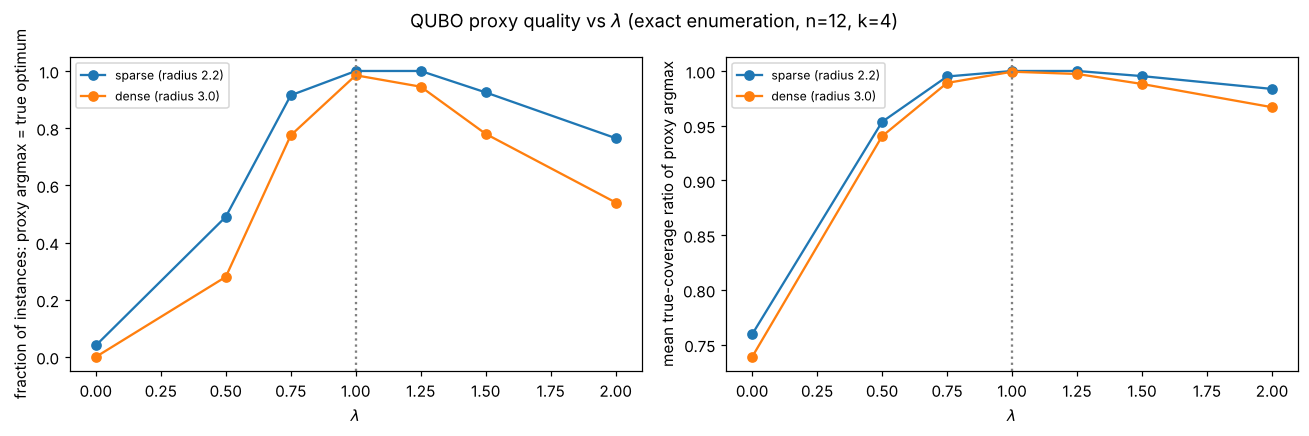

best lambda per family: {'sparse (radius 2.2)': 1.0, 'dense (radius 3.0)': 1.0} | fraction proxy-exact at lambda=1: {'sparse (radius 2.2)': 1.0, 'dense (radius 3.0)': 0.985}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fam in LAMBDA_FAMILIES:
    t = lam_df[lam_df.family == fam].groupby('lambda')
    axes[0].plot(LAMBDA_GRID, t['exact'].mean(), 'o-', label=fam)
    axes[1].plot(LAMBDA_GRID, t['ratio_worst_tie'].mean(), 'o-', label=fam)
axes[0].set_ylabel('fraction of instances: proxy argmax = true optimum')
axes[1].set_ylabel('mean true-coverage ratio of proxy argmax')
for ax in axes:
    ax.axvline(1.0, color='gray', ls=':')
    ax.set_xlabel(r'$\lambda$'); ax.legend(fontsize=8)
fig.suptitle(r'QUBO proxy quality vs $\lambda$ (exact enumeration, n=12, k=4)')
plt.tight_layout(); plt.show()

lam_star = {fam: float(lam_df[lam_df.family == fam].groupby('lambda')['exact'].mean().idxmax()) for fam in LAMBDA_FAMILIES}
proxy_exact_rate = {fam: float(lam_df[(lam_df.family == fam) & (lam_df['lambda'] == 1.0)]['exact'].mean()) for fam in LAMBDA_FAMILIES}
print('best lambda per family:', lam_star, '| fraction proxy-exact at lambda=1:', proxy_exact_rate)

**Reading.** The table and plot are the evidence for keeping $\lambda = 1$ in the rest of the
notebook (fixed before any QAOA run, not re-tuned per instance). $\lambda = 0$ (plain sum of
individual coverages) almost never finds the optimum, so the overlap term is doing real work;
values away from 1 in either direction degrade quickly, as the zone-contribution table predicts.
At $\lambda = 1$ the proxy is exact on all sparse instances and on all but a few dense ones: zones
covered three or more times by an optimal selection are rare at these densities (well below 1%),
which is why the truncation costs so little here. On denser instances, or with larger $k$, it
would cost more. All QAOA results below are reported against the **true** coverage, so any
proxy error is included in them.

## 2. Illustrative case study: Vienna

A single map, kept to make the problem concrete. Real anchors are individually sourced; the
rest of the candidate pool is reproducible synthetic infill inside the same bounding box,
labelled as such. No conclusion in this notebook rests on this single instance.

In [5]:
REGIONS = {
    'milano': {'display_name': 'Milano', 'bbox': (45.40, 45.53, 9.05, 9.28), 'anchors': [
        {'name': 'Duomo', 'lat': 45.4642, 'lon': 9.1900, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Stazione Centrale', 'lat': 45.4859, 'lon': 9.2044, 'source': 'general knowledge (not individually verified)'},
        {'name': 'San Siro', 'lat': 45.4781, 'lon': 9.1240, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Bicocca', 'lat': 45.5150, 'lon': 9.2100, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Bocconi', 'lat': 45.4505, 'lon': 9.1868, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Città Studi', 'lat': 45.4780, 'lon': 9.2280, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Navigli - Darsena', 'lat': 45.4515, 'lon': 9.1739, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Parco Sempione', 'lat': 45.4730, 'lon': 9.1770, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Certosa', 'lat': 45.5030, 'lon': 9.1450, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Aeroporto di Linate', 'lat': 45.4451, 'lon': 9.2767, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Famagosta', 'lat': 45.4380, 'lon': 9.1560, 'source': 'general knowledge (not individually verified)'},
        {'name': 'Lambrate', 'lat': 45.4840, 'lon': 9.2330, 'source': 'general knowledge (not individually verified)'}]},
    'salerno': {'display_name': 'Salerno', 'bbox': (40.63, 40.80, 14.70, 14.90), 'anchors': [
        {'name': 'Stazione di Salerno', 'lat': 40.68333, 'lon': 14.76667, 'source': 'Wikipedia — Salerno railway station'},
        {'name': 'Fisciano (campus Unisa)', 'lat': 40.767, 'lon': 14.800, 'source': 'Wikipedia — Fisciano'}]},
    'lamezia_gizzeria': {'display_name': 'Lamezia Terme – Gizzeria', 'bbox': (38.88, 39.00, 16.15, 16.32), 'anchors': [
        {'name': 'Aeroporto di Lamezia Terme (SUF)', 'lat': 38.90528, 'lon': 16.24222, 'source': 'Wikipedia — Lamezia Terme International Airport'},
        {'name': 'Stazione di Lamezia Terme Centrale', 'lat': 38.92111, 'lon': 16.25556, 'source': 'Wikipedia — Lamezia Terme Centrale railway station'},
        {'name': 'Lamezia Terme (Nicastro, centro)', 'lat': 38.967, 'lon': 16.300, 'source': 'Wikipedia — Lamezia Terme'},
        {'name': 'Gizzeria (centro collinare)', 'lat': 38.98056, 'lon': 16.20556, 'source': 'Wikipedia — Gizzeria'},
        {'name': 'Lago La Vota / costa di Gizzeria', 'lat': 38.94194, 'lon': 16.18833, 'source': 'Wikipedia — La Vota Lake'}]},
    'foligno': {'display_name': 'Foligno', 'bbox': (42.90, 43.00, 12.62, 12.80), 'anchors': [
        {'name': 'Stazione di Foligno', 'lat': 42.95444, 'lon': 12.71111, 'source': 'Wikipedia — Foligno railway station'},
        {'name': 'Piazza della Repubblica', 'lat': 42.9564, 'lon': 12.7029, 'source': 'Wikidata — Piazza della Repubblica (Foligno)'}]},
    'rimini': {'display_name': 'Rimini', 'bbox': (44.00, 44.12, 12.48, 12.62), 'anchors': [
        {'name': 'Stazione di Rimini', 'lat': 44.06389, 'lon': 12.57400, 'source': 'Wikipedia — Rimini railway station'},
        {'name': 'Rimini Viserba', 'lat': 44.0861, 'lon': 12.5317, 'source': 'Wikidata — Rimini Viserba railway station'}]},
    'reggio_calabria': {'display_name': 'Reggio Calabria', 'bbox': (38.05, 38.16, 15.58, 15.72), 'anchors': [
        {'name': 'Reggio Calabria (centro / Piazza Garibaldi)', 'lat': 38.11139, 'lon': 15.66194, 'source': 'Wikipedia — Reggio Calabria'},
        {'name': 'Stazione di Reggio Calabria Santa Caterina', 'lat': 38.12635, 'lon': 15.65263, 'source': 'Wikipedia — Reggio di Calabria Santa Caterina railway station'}]},
    'vienna': {'display_name': 'Vienna', 'bbox': (48.15, 48.25, 16.28, 16.46), 'anchors': [
        {'name': 'Wien Hauptbahnhof', 'lat': 48.1867, 'lon': 16.3800, 'source': 'Wikipedia — Wien Hauptbahnhof'},
        {'name': 'Stephansplatz', 'lat': 48.2080, 'lon': 16.3716, 'source': 'Wikidata — Stephansplatz'},
        {'name': 'Wien Westbahnhof', 'lat': 48.1967, 'lon': 16.3378, 'source': 'Wikipedia — Wien Westbahnhof railway station'},
        {'name': 'Karlsplatz', 'lat': 48.2007, 'lon': 16.3689, 'source': 'Wikipedia — Karlsplatz station (Vienna U-Bahn)'}]},
    'gstaad': {'display_name': 'Gstaad', 'bbox': (46.35, 46.55, 7.20, 7.40), 'anchors': [
        {'name': 'Gstaad (centro paese)', 'lat': 46.467, 'lon': 7.283, 'source': 'Wikipedia — Gstaad'},
        {'name': 'Gsteig bei Gstaad', 'lat': 46.383, 'lon': 7.267, 'source': 'Wikipedia — Gsteig bei Gstaad'},
        {'name': 'Rinderberg (area sciistica)', 'lat': 46.505, 'lon': 7.357, 'source': 'Wikipedia — Rinderberg'}]},
    'zurigo': {'display_name': 'Zurigo', 'bbox': (47.35, 47.48, 8.48, 8.60), 'anchors': [
        {'name': 'Zürich Hauptbahnhof', 'lat': 47.378169, 'lon': 8.540178, 'source': 'Wikipedia — Zürich Hauptbahnhof'},
        {'name': 'ETH Zürich (Hauptgebäude)', 'lat': 47.3765, 'lon': 8.5479, 'source': 'Wikidata — ETH Zurich main building'},
        {'name': 'Aeroporto di Zurigo (ZRH)', 'lat': 47.46472, 'lon': 8.54917, 'source': 'Wikipedia — Zurich Airport'}]},
    'losanna': {'display_name': 'Losanna', 'bbox': (46.46, 46.58, 6.50, 6.70), 'anchors': [
        {'name': 'Losanna, Gare CFF', 'lat': 46.5168, 'lon': 6.6291, 'source': 'Wikipedia — Lausanne railway station'},
        {'name': 'EPFL (Ecublens)', 'lat': 46.5222, 'lon': 6.5661, 'source': 'Wikidata — EPFL metro station'}]},
}

REGION = 'vienna'
CSV_PATH = None      # a real station CSV takes precedence over anchors + synthetic infill
COLUMN_MAP = None    # e.g. {'lat': 'Latitudine', 'lon': 'Longitudine', 'name': 'Denominazione'}
N_STATIONS, N_ZONES_SIDE, COVERAGE_RADIUS_KM, K_STATIONS, LAMBDA_OVERLAP = 12, 5, 3.5, 4, 1.0
SYNTH = 'synthetic infill (reproducible random, not a real location)'


def load_stations(csv_path, column_map, region, n_stations, seed):
    if csv_path is not None:
        df = pd.read_csv(csv_path)
        cols = {c.lower(): c for c in df.columns}
        pick = lambda cands, key: (column_map or {}).get(key) or next((cols[c] for c in cands if c in cols), None)
        lat_c = pick(['lat', 'latitude', 'latitudine', 'y'], 'lat')
        lon_c = pick(['lon', 'lng', 'long', 'longitude', 'longitudine', 'x'], 'lon')
        name_c = pick(['nome', 'denominazione', 'nomestazione', 'name', 'stazione', 'station'], 'name')
        if lat_c is None or lon_c is None:
            raise ValueError(f"cannot find lat/lon columns in {list(df.columns)}; set COLUMN_MAP")
        return pd.DataFrame({'name': df[name_c] if name_c else [f'station_{i}' for i in range(len(df))],
                             'lat': df[lat_c].astype(float), 'lon': df[lon_c].astype(float),
                             'source': f'CSV: {csv_path}'}).dropna(subset=['lat', 'lon']).reset_index(drop=True)
    rows = [dict(a) for a in region['anchors']][:n_stations]
    rng = np.random.default_rng(seed)
    lat_min, lat_max, lon_min, lon_max = region['bbox']
    for i in range(n_stations - len(rows)):
        rows.append({'name': f'synthetic_{i}', 'lat': rng.uniform(lat_min, lat_max),
                     'lon': rng.uniform(lon_min, lon_max), 'source': SYNTH})
    return pd.DataFrame(rows)[['name', 'lat', 'lon', 'source']]


def define_zones(bbox, n_side):
    lat_min, lat_max, lon_min, lon_max = bbox
    la, lo = np.linspace(lat_min, lat_max, n_side + 1), np.linspace(lon_min, lon_max, n_side + 1)
    return pd.DataFrame([{'zone_id': f'z{i}_{j}', 'lat': (la[i] + la[i + 1]) / 2, 'lon': (lo[j] + lo[j + 1]) / 2}
                         for i in range(n_side) for j in range(n_side)])


def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin(np.radians(lat2 - lat1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))


stations = load_stations(CSV_PATH, COLUMN_MAP, REGIONS[REGION], N_STATIONS, SEED)
zones = define_zones(REGIONS[REGION]['bbox'], N_ZONES_SIDE)
dist_km = haversine_km(stations['lat'].values[:, None], stations['lon'].values[:, None],
                       zones['lat'].values[None, :], zones['lon'].values[None, :])
cov_city = (dist_km <= COVERAGE_RADIUS_KM).astype(int)
city = Instance(cov_city, K_STATIONS, LAMBDA_OVERLAP, name=REGION)
is_real = (stations['source'] != SYNTH).values
print(f"{REGIONS[REGION]['display_name']}: {is_real.sum()} sourced anchors + {(~is_real).sum()} synthetic points, "
      f"{len(zones)} zones, k={K_STATIONS}, radius {COVERAGE_RADIUS_KM} km")
print(f"coverage per zone min/mean/max: {cov_city.sum(0).min()}/{cov_city.sum(0).mean():.1f}/{cov_city.sum(0).max()}; "
      f"per station: {cov_city.sum(1).min()}/{cov_city.sum(1).mean():.1f}/{cov_city.sum(1).max()}")
stations

Vienna: 4 sourced anchors + 8 synthetic points, 25 zones, k=4, radius 3.5 km
coverage per zone min/mean/max: 0/2.8/6; per station: 2/5.8/8


,name,lat,lon,source
0,Wien Hauptbahnhof,48.186700,16.380000,Wikipedia — Wien Hauptbahnhof
1,Stephansplatz,48.208000,16.371600,Wikidata — Stephansplatz
2,Wien Westbahnhof,48.196700,16.337800,Wikipedia — Wien Westbahnhof railway station
3,Karlsplatz,48.200700,16.368900,Wikipedia — Karlsplatz station (Vienna U-Bahn)
4,synthetic_0,48.227396,16.358998,"synthetic infill (reproducible random, not a r..."
5,synthetic_1,48.235860,16.405526,"synthetic infill (reproducible random, not a r..."
6,synthetic_2,48.159418,16.455612,"synthetic infill (reproducible random, not a r..."
7,synthetic_3,48.226114,16.421492,"synthetic infill (reproducible random, not a r..."
8,synthetic_4,48.162811,16.361069,"synthetic infill (reproducible random, not a r..."
9,synthetic_5,48.187080,16.446818,"synthetic infill (reproducible random, not a r..."


In [6]:
def classical_baselines(inst, seed):
    sel_g, v_g = greedy_selection(inst.cov, inst.k)
    sel_l, v_l, x_lp, ub = lp_topk(inst.cov, inst.k)
    _, v_lr, _ = lp_randomized_rounding(inst.cov, inst.k, seed=seed)
    sel_sa, _ = simulated_annealing(inst.cov, inst.k, inst.lam, seed=seed)
    worst_proxy, _ = proxy_argmax_ratio(inst)
    return {'greedy': v_g / inst.opt, 'lp_topk': v_l / inst.opt, 'lp_rand_round': v_lr / inst.opt,
            'sim_annealing': true_coverage(sel_sa, inst.cov) / inst.opt, 'proxy_exact': worst_proxy,
            'random_mean': inst.random_mean_ratio, 'lp_fractional': float(np.mean((x_lp > 1e-6) & (x_lp < 1 - 1e-6))),
            'lp_bound_over_opt': ub / inst.opt}


z_city = np.where(city.feas & (city.tc == city.opt))[0]
city_base = classical_baselines(city, SEED)
print(f"optimum {city.opt}/{len(zones)} (attained by {len(z_city)} selection(s), e.g. {bits_to_sel(z_city[0], city.n)})")
print(pd.Series(city_base).round(3).to_string())

optimum 21/25 (attained by 2 selection(s), e.g. [2, 5, 8, 9])
greedy               0.905
lp_topk              1.000
lp_rand_round        1.000
sim_annealing        1.000
proxy_exact          1.000
random_mean          0.747
lp_fractional        0.000
lp_bound_over_opt    1.000


## 3. Methods

**Ansätze** (cost diagonal $C$ from Section 1, all integer-valued):

| Name | Initial state | Cost layer | Mixer layer | Parameters |
|---|---|---|---|---|
| Penalty QAOA ($P_\text{auto}$ or $P_\text{tight}$) | $\lvert+\rangle^{\otimes n}$ | $e^{-i\gamma_l C}$, $C = -g_1 + P(\sum x - k)^2$ | $e^{-i\beta_l \sum_i X_i}$ | $2p$ |
| XY-mixer QAOA, basis start | $\lvert 1^k 0^{n-k}\rangle$ | $e^{-i\gamma_l C}$, $C = -g_1$ | $\prod_{i} e^{-i\beta_l (X_iX_{i+1}+Y_iY_{i+1})/2}$ (ring) | $2p$ |
| XY-mixer QAOA, Dicke start | $\lvert D^n_k\rangle$ (uniform over weight $k$) | same | same | $2p$ |

The ring mixer is applied as one Trotter step (hops in ring order). Each hop conserves Hamming
weight exactly, so the product does too: Trotter error changes *which* feasible state is
reached, never feasibility. The basis start is the one used on hardware (Section 8): it costs
$k$ X gates. The Dicke start is the feasible-subspace analogue of $\lvert+\rangle^{\otimes n}$; it removes the
dependence on which $k$ stations happen to be labelled $0..k-1$, but preparing it on hardware
costs $O(kn)$ extra two-qubit gates (Bärtschi & Eidenbenz 2019), which Section 7 does not
count — it is included here as an upper reference for what the mixer can do in simulation.

**Simulator.** Circuits of this size ($2^{14} = 16384$ amplitudes) are simulated exactly with a
small numpy simulator (library cell above), because the study needs ~$10^7$ energy evaluations
and exact gradients. It is validated against Qiskit below: states against `Statevector` of
the corresponding Qiskit circuits, gradients against `ReverseEstimatorGradient`.

**Metrics** (computed from exact output probabilities, so no shot noise):
- `p_feasible`: probability that a shot satisfies the budget (always 1 for the XY mixer in simulation);
- `ratio_cond`: expected true-coverage ratio $f(x)/f^\star$ of a feasible shot;
- `p_opt`: probability that one shot is a true optimum ($1/p_\text{opt}$ = expected shots to solution);
- `best_of_S`: expected ratio of the best of $S$ shots, infeasible shots scoring 0 — the quantity
  a practitioner actually gets, and the one that the previous version's `MinimumEigenOptimizer`
  reported implicitly with $S \approx 1000$;
- `ratio_top1`: ratio of the single most probable feasible bitstring (what the previous version
  reported for the native mixer; kept for continuity, but it can be misleading — see Result 1).

Every metric is compared with the **classical null** of drawing uniformly random $k$-subsets.

**Optimisation.** COBYLA (SciPy), the same budget for every method, restarts from seeded random
points, and the restart with the lowest *energy* is kept (never selected by true coverage).
Since the methods' cost operators have very different scales, $\gamma$ is optimised in units of
$\gamma_\text{scale}/\max|a_S|$, with $a_S$ the Pauli coefficients of $C$; $\gamma_\text{scale}$ is chosen per method
on separate calibration instances (by final energy, again not by coverage).

In [7]:
def qiskit_penalty_op(inst, P):
    qp_ = QuadraticProgram('max_coverage_proxy')
    for i in range(inst.n):
        qp_.binary_var(f'x{i}')
    qp_.maximize(linear={f'x{i}': float(inst.c[i]) for i in range(inst.n)},
                 quadratic={(f'x{i}', f'x{j}'): -inst.lam * float(inst.O[i, j])
                            for i in range(inst.n) for j in range(i + 1, inst.n) if inst.O[i, j] > 0})
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(inst.n)}, sense='==', rhs=inst.k, name='budget')
    conv = QuadraticProgramToQubo(penalty=P)
    op, offset = conv.convert(qp_).to_ising()
    return op, offset, conv.penalty


def diag_to_sparse_pauli(diag):
    """SparsePauliOp (Z terms only) equal to diag minus its constant term."""
    n = int(np.log2(diag.size))
    a = z_coeffs(diag)
    terms = []
    for S in range(1, diag.size):
        if abs(a[S]) > 1e-12:
            terms.append((''.join('Z' if (S >> (n - 1 - j)) & 1 else 'I' for j in range(n)), a[S]))
    return SparsePauliOp.from_list(terms), a[0]


def qiskit_native_circuit(inst, p, H_C):
    """Explicit Qiskit circuit for the XY-mixer QAOA with basis start, hop order = gates_ring_xy.
    XXPlusYYGate(theta) = exp(-i theta/4 (XX+YY)), so theta = 2 beta gives exp(-i beta (XX+YY)/2)."""
    g, b = ParameterVector('g', p), ParameterVector('b', p)
    qc = QuantumCircuit(inst.n)
    for i in range(inst.k):
        qc.x(i)
    for l in range(p):
        qc.append(PauliEvolutionGate(H_C, time=g[l]), range(inst.n))
        for a_, b_ in ring_pairs(inst.n):
            qc.append(XXPlusYYGate(2 * b[l]), [a_, b_])
    return qc


val_rows = []
for seed in range(3):
    inst_v = Instance(make_instance(10, seed=700 + seed), 3)
    th = np.random.default_rng(seed).uniform(0, 2 * np.pi, 4)          # p = 2: [g0, g1, b0, b1]
    # (1) automatic penalty: our formula vs qiskit-optimization's converter
    op_auto, off_auto, P_qiskit = qiskit_penalty_op(inst_v, None)
    d_auto = cost_diag(inst_v, 'penalty_auto')
    diag_err = np.abs(np.real(op_auto.to_matrix(sparse=True).diagonal()) + off_auto - d_auto).max()
    # (2) penalty QAOA state vs qiskit QAOAAnsatz (parameter order there: beta..., gamma...)
    sim_v, g_v, psi0_v, _ = ansatz_for(inst_v, 'penalty_auto', 2)
    sv = Statevector(QAOAAnsatz(op_auto, reps=2).assign_parameters(np.r_[th[2:], th[:2]])).data
    fid_pen = abs(np.vdot(sv, sim_v.state(psi0_v, g_v, th))) ** 2
    # (3) XY-mixer QAOA state vs explicit qiskit circuit
    H_C_v, _ = diag_to_sparse_pauli(cost_diag(inst_v, 'native'))
    sim_n, g_n, psi0_n, d_n = ansatz_for(inst_v, 'native', 2)
    qc_n = qiskit_native_circuit(inst_v, 2, H_C_v)
    sv_n = Statevector(qc_n.assign_parameters(np.r_[th[2:], th[:2]])).data
    psi_n = sim_n.state(psi0_n, g_n, th)
    fid_nat = abs(np.vdot(sv_n, psi_n)) ** 2
    wrong_weight = float(np.abs(psi_n[~inst_v.feas]).max())
    # (4) adjoint gradient vs qiskit's exact reverse-mode gradient
    from qiskit_algorithms.gradients import ReverseEstimatorGradient
    qc_dec = transpile(qc_n, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=0)
    g_qk = ReverseEstimatorGradient().run([qc_dec], [H_C_v], [np.r_[th[2:], th[:2]]]).result().gradients[0]
    _, g_ours = sim_n.energy_and_grad(psi0_n, g_n, th, d_n, 4)
    grad_err = np.abs(np.r_[g_ours[2:], g_ours[:2]] - g_qk).max()
    tight_ok = bool(np.all(inst_v.feas[cost_diag(inst_v, 'penalty_tight') <= cost_diag(inst_v, 'penalty_tight').min() + 1e-9]))
    val_rows.append({'instance': seed, 'P_auto (ours)': penalty_auto(inst_v), 'P_auto (qiskit)': P_qiskit,
                     'max |diag error|': diag_err, '1-fidelity penalty': 1 - fid_pen, '1-fidelity XY': 1 - fid_nat,
                     'max amp outside weight k': wrong_weight, 'max |grad error|': grad_err,
                     'P_tight': penalty_tight(inst_v), 'P_tight minimiser feasible': tight_ok})
val_df = pd.DataFrame(val_rows)
display(val_df)
assert (val_df['P_auto (ours)'] == val_df['P_auto (qiskit)']).all()
assert val_df['max |diag error|'].max() < 1e-9 and val_df['1-fidelity penalty'].max() < 1e-9
assert val_df['1-fidelity XY'].max() < 1e-9 and val_df['max amp outside weight k'].max() < 1e-12
assert val_df['max |grad error|'].max() < 1e-8 and val_df['P_tight minimiser feasible'].all()

# hardware-efficient reference ansatz (used in Section 6) vs qiskit's real_amplitudes
th_ra = np.random.default_rng(5).uniform(0, 2 * np.pi, 6 * 3)
g_ra, n_ra = gates_real_amplitudes(6, 2)
fid_ra = abs(np.vdot(Statevector(real_amplitudes(6, reps=2, entanglement='linear').assign_parameters(th_ra)).data,
                     Sim(6).state(first_k_state(6, 0), g_ra, th_ra))) ** 2
assert 1 - fid_ra < 1e-9
print('All validation checks passed (simulator states, gradients, penalties).')

,instance,P_auto (ours),P_auto (qiskit),max |diag error|,1-fidelity penalty,1-fidelity XY,max amp outside weight k,max |grad error|,P_tight,P_tight minimiser feasible
0,0,46.0,46.0,0.0,1.998401e-15,4.440892e-16,0.0,1.043610e-14,6.0,True
1,1,53.0,53.0,0.0,8.792966e-14,6.661338e-16,0.0,1.509903e-14,10.0,True
2,2,60.0,60.0,0.0,2.464695e-14,2.220446e-16,0.0,1.479372e-14,7.0,True


All validation checks passed (simulator states, gradients, penalties).


In [8]:
# Calibration of gamma_scale per method, on instances never used again (seeds 50000+).
GAMMA_SCALE_GRID = [0.1, 0.3, 1.0, 3.0]
N_CAL, CAL_N, CAL_P, CAL_RESTARTS = 6, 10, 2, 2
MAXITER, N_RESTARTS = 250, 4

cal_insts = [Instance(make_instance(CAL_N, seed=50000 + s), round(CAL_N / 3)) for s in range(N_CAL)]
cal_rows = []
for method in METHODS:
    for gs in GAMMA_SCALE_GRID:
        for i, inst_c in enumerate(cal_insts):
            _, _, e_fin, _, _ = optimise_qaoa(inst_c, method, CAL_P, CAL_RESTARTS, seed=10 * i, gamma_scale=gs, maxiter=MAXITER)
            d = cost_diag(inst_c, method)
            dom = d[inst_c.feas] if method.startswith('native') else d    # spectrum the circuit can reach
            cal_rows.append({'method': method, 'gamma_scale': gs, 'normalised_final_energy': (e_fin - dom.min()) / (dom.max() - dom.min())})
cal_df = pd.DataFrame(cal_rows).groupby(['method', 'gamma_scale'])['normalised_final_energy'].mean().unstack()
GAMMA_SCALE = {m: float(cal_df.loc[m].idxmin()) for m in METHODS}
display(cal_df.round(4))
print('chosen gamma_scale:', GAMMA_SCALE)

gamma_scale,0.1,0.3,1.0,3.0
method,,,,
native,0.2316,0.2317,0.2295,0.2173
native_dicke,0.3071,0.3003,0.3244,0.3353
penalty_auto,0.0166,0.0164,0.0232,0.0648
penalty_tight,0.0286,0.0284,0.0464,0.0912


chosen gamma_scale: {'penalty_auto': 0.3, 'penalty_tight': 0.3, 'native': 3.0, 'native_dicke': 0.3}


## 4. Instance ensembles and classical hardness

Two families, both with 25 zones in a $10\times10$ box:

- **R (random)**: radius 2.2, $n \in \{8, 10, 12, 14\}$, $k = \mathrm{round}(n/3)$; the distribution of the previous
  version, now with more instances and variable $n$.
- **H (classically hard)**: radius 3.0, $n = 12$, $k = 4$, *rejection-sampled* so that greedy **and**
  deterministic LP rounding both miss the optimum. These are rare (see the rates printed below), which is
  itself a result: on geometric instances of this size the LP relaxation is almost always integral.

All QAOA instances use seeds disjoint from the calibration set.

In [9]:
ENSEMBLE_SIZES = {8: 20, 10: 20, 12: 20, 14: 12}
N_HARD, HARD_N, HARD_K, HARD_RADIUS = 12, 12, 4, 3.0

ensemble = []      # list of (family, Instance)
for n_, count in ENSEMBLE_SIZES.items():
    for s in range(count):
        ensemble.append(('R', Instance(make_instance(n_, seed=1000 * n_ + s), round(n_ / 3), name=f'R-n{n_}-s{s}')))

hard_scan, s = 0, 0
while sum(f == 'H' for f, _ in ensemble) < N_HARD:
    cov_h = make_instance(HARD_N, seed=900000 + s, radius=HARD_RADIUS)
    inst_h = Instance(cov_h, HARD_K, name=f'H-n{HARD_N}-s{s}')
    if greedy_selection(cov_h, HARD_K)[1] < inst_h.opt and lp_topk(cov_h, HARD_K)[1] < inst_h.opt:
        ensemble.append(('H', inst_h))
    s += 1
hard_scan = s
print(f"family H: {N_HARD} instances found among {hard_scan} draws ({N_HARD / hard_scan:.1%})")

base_rows = []
for fam, inst_e in ensemble:
    b = classical_baselines(inst_e, seed=SEED)
    base_rows.append({'family': fam, 'n': inst_e.n, 'k': inst_e.k, 'instance': inst_e.name, 'opt': inst_e.opt, **b})
base_df = pd.DataFrame(base_rows)
base_df.to_csv(f'{RESULTS_DIR}/classical_baselines.csv', index=False)

agg = base_df.groupby(['family', 'n']).agg(
    instances=('opt', 'size'), random_mean=('random_mean', 'mean'),
    greedy_mean=('greedy', 'mean'), greedy_fail=('greedy', lambda x: np.mean(x < 1)),
    lp_topk_mean=('lp_topk', 'mean'), lp_topk_fail=('lp_topk', lambda x: np.mean(x < 1)),
    lp_rand_round_fail=('lp_rand_round', lambda x: np.mean(x < 1)), sa_fail=('sim_annealing', lambda x: np.mean(x < 1)),
    proxy_fail=('proxy_exact', lambda x: np.mean(x < 1)), lp_fractional=('lp_fractional', 'mean')).round(3)
display(agg)

# base rates of greedy / LP failure on the unfiltered distributions (classical only, cheap)
rate_rows = []
for radius in [2.2, 3.0]:
    for n_ in [8, 10, 12, 14]:
        k_ = round(n_ / 3)
        fails = [(greedy_selection(c_, k_)[1] < o_, lp_topk(c_, k_)[1] < o_)
                 for c_ in (make_instance(n_, seed=400000 + 1000 * n_ + s_, radius=radius) for s_ in range(200))
                 for o_ in [Instance(c_, k_).opt]]
        fails = np.array(fails)
        rate_rows.append({'radius': radius, 'n': n_, 'greedy_fails': fails[:, 0].mean(), 'lp_topk_fails': fails[:, 1].mean(),
                          'both_fail': (fails[:, 0] & fails[:, 1]).mean()})
rates_df = pd.DataFrame(rate_rows)
display(rates_df.pivot(index='n', columns='radius').round(3))

family H: 12 instances found among 3682 draws (0.3%)


instances  random_mean  greedy_mean  greedy_fail  lp_topk_mean  lp_topk_fail  lp_rand_round_fail  sa_fail  proxy_fail  lp_fractional
family n                                                                                                                                       
H      12         12        0.726        0.945         1.00         0.928           1.0               0.083      0.0         0.0          0.375
R      8          20        0.635        0.997         0.05         1.000           0.0               0.000      0.0         0.0          0.000
       10         20        0.626        0.997         0.05         1.000           0.0               0.000      0.0         0.0          0.000
       12         20        0.653        0.996         0.05         1.000           0.0               0.000      0.0         0.0          0.000
       14         12        0.661        1.000         0.00         1.000           0.0               0.000      0.0         0.0          0.000

greedy_fails        lp_topk_fails        both_fail       
radius          2.2    3.0           2.2    3.0       2.2    3.0
n                                                               
8             0.065  0.155         0.005  0.010       0.0  0.000
10            0.040  0.145         0.000  0.030       0.0  0.005
12            0.085  0.295         0.010  0.025       0.0  0.005
14            0.190  0.210         0.000  0.000       0.0  0.000

**Reading.** On family R every classical method finds the optimum (greedy on all but 3 of
the 72 instances), and the LP relaxation is integral on every instance. Instances on which both
greedy and LP rounding fail are rare even in the denser distribution (well under 1% of draws).
At this scale the problem is classically easy and exhaustive enumeration is instantaneous.
Family H exists so that the QAOA comparison is not made only on instances where the LP hands
over the answer — but "hard for greedy and LP rounding" is still easy for simulated annealing
and, on almost all H instances, for randomized LP rounding (see the table). Conclusions below
are therefore about the *relative* behaviour of the two encodings, not about beating classical
methods.

## 5. Result 1 — solution quality at fixed depth

Same instances, same optimiser budget (COBYLA, `MAXITER` iterations × `N_RESTARTS` seeded
restarts), same metrics, for the four methods and $p \in \{1, 2, 3\}$. 95% confidence intervals are
percentile bootstraps over instances.

In [10]:
P_LIST = [1, 2, 3]
SHOTS_LIST = (1, 10, 100, 1000)

quality_rows = []
t0 = time.time()
for e_idx, (fam, inst_e) in enumerate(ensemble):
    rnd = random_metrics(inst_e, SHOTS_LIST)
    quality_rows.append({'family': fam, 'n': inst_e.n, 'instance': inst_e.name, 'method': 'random', 'p': 0, **rnd})
    for method in METHODS:
        for p in P_LIST:
            _, probs, e_fin, nfev, _ = optimise_qaoa(inst_e, method, p, N_RESTARTS, seed=SEED + 97 * e_idx + 7 * p,
                                                   gamma_scale=GAMMA_SCALE[method], maxiter=MAXITER)
            quality_rows.append({'family': fam, 'n': inst_e.n, 'instance': inst_e.name, 'method': method, 'p': p,
                                 'nfev': nfev, **output_metrics(inst_e, probs, SHOTS_LIST)})
    if (e_idx + 1) % 12 == 0:
        print(f"{e_idx + 1}/{len(ensemble)} instances  [{time.time() - t0:.0f}s]")
quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(f'{RESULTS_DIR}/quality_per_instance.csv', index=False)
print(f"done in {time.time() - t0:.0f}s")

12/84 instances  [135s]


24/84 instances  [279s]


36/84 instances  [435s]


48/84 instances  [636s]


60/84 instances  [863s]


72/84 instances  [1366s]


84/84 instances  [1591s]
done in 1591s


In [11]:
METRICS_SHOWN = ['p_feasible', 'ratio_cond', 'p_opt', 'best_of_10', 'best_of_1000', 'ratio_top1']


def quality_table(df, family, ns=None):
    rows = []
    sub = df[df.family == family]
    for n_ in sorted(sub.n.unique()) if ns is None else ns:
        for method in ['random'] + METHODS:
            for p in ([0] if method == 'random' else P_LIST):
                s_ = sub[(sub.n == n_) & (sub.method == method) & (sub.p == p)]
                row = {'n': n_, 'method': method, 'p': p}
                for m in METRICS_SHOWN:
                    row[m] = fmt_ci(boot_ci(s_[m].values, seed=1)) if s_[m].notna().any() else '—'
                rows.append(row)
    return pd.DataFrame(rows)


print('Family R, n = 12 (other n in results/quality_table_R.csv):')
qt_R = quality_table(quality_df, 'R')
qt_R.to_csv(f'{RESULTS_DIR}/quality_table_R.csv', index=False)
display(qt_R[qt_R.n == 12].set_index(['method', 'p']).drop(columns='n'))
print('Family H (classically hard), n = 12:')
qt_H = quality_table(quality_df, 'H')
qt_H.to_csv(f'{RESULTS_DIR}/quality_table_H.csv', index=False)
display(qt_H.set_index(['method', 'p']).drop(columns='n'))

Family R, n = 12 (other n in results/quality_table_R.csv):


p_feasible            ratio_cond                 p_opt            best_of_10          best_of_1000            ratio_top1
method        p                                                                                                                                    
random        0  1.000 [1.000, 1.000]  0.653 [0.627, 0.678]  0.011 [0.007, 0.017]  0.869 [0.853, 0.885]  0.999 [0.997, 1.000]                     —
penalty_auto  1  0.444 [0.443, 0.444]  0.653 [0.627, 0.679]  0.005 [0.003, 0.007]  0.802 [0.781, 0.821]  0.994 [0.990, 0.997]  0.991 [0.975, 1.000]
              2  0.536 [0.513, 0.562]  0.654 [0.628, 0.679]  0.006 [0.004, 0.009]  0.821 [0.801, 0.840]  0.995 [0.992, 0.998]  0.986 [0.963, 1.000]
              3  0.567 [0.546, 0.587]  0.653 [0.628, 0.679]  0.006 [0.004, 0.009]  0.826 [0.806, 0.844]  0.996 [0.993, 0.998]  0.851 [0.762, 0.928]
penalty_tight 1  0.432 [0.429, 0.436]  0.659 [0.634, 0.684]  0.005 [0.003, 0.008]  0.803 [0.783, 0.822]  0.994 [0.990, 0.998]  0.991 [0.975, 1.000]
              2  0.521 [0.497, 0.546]  0.662 [0.637, 0.686]  0.007 [0.004, 0.010]  0.824 [0.804, 0.843]  0.996 [0.993, 0.999]  0.996 [0.989, 1.000]
              3  0.554 [0.527, 0.580]  0.659 [0.634, 0.684]  0.007 [0.004, 0.010]  0.828 [0.809, 0.846]  0.996 [0.993, 0.999]  0.901 [0.823, 0.964]
native        1  1.000 [1.000, 1.000]  0.748 [0.680, 0.816]  0.000 [0.000, 0.000]  0.793 [0.724, 0.855]  0.803 [0.731, 0.868]  0.747 [0.676, 0.817]
              2  1.000 [1.000, 1.000]  0.794 [0.746, 0.845]  0.006 [0.000, 0.017]  0.867 [0.840, 0.893]  0.915 [0.898, 0.933]  0.789 [0.734, 0.843]
              3  1.000 [1.000, 1.000]  0.811 [0.766, 0.859]  0.029 [0.000, 0.076]  0.880 [0.849, 0.910]  0.919 [0.895, 0.943]  0.814 [0.768, 0.859]
native_dicke  1  1.000 [1.000, 1.000]  0.767 [0.750, 0.785]  0.044 [0.028, 0.065]  0.937 [0.926, 0.948]  1.000 [1.000, 1.000]  0.928 [0.891, 0.956]
              2  1.000 [1.000, 1.000]  0.788 [0.765, 0.809]  0.064 [0.042, 0.093]  0.948 [0.935, 0.960]  1.000 [0.999, 1.000]  0.898 [0.836, 0.945]
              3  1.000 [1.000, 1.000]  0.795 [0.771, 0.816]  0.073 [0.048, 0.103]  0.951 [0.936, 0.964]  0.999 [0.998, 1.000]  0.915 [0.881, 0.942]

Family H (classically hard), n = 12:


p_feasible            ratio_cond                 p_opt            best_of_10          best_of_1000            ratio_top1
method        p                                                                                                                                    
random        0  1.000 [1.000, 1.000]  0.726 [0.708, 0.746]  0.010 [0.007, 0.016]  0.909 [0.899, 0.918]  1.000 [1.000, 1.000]                     —
penalty_auto  1  0.444 [0.444, 0.444]  0.727 [0.709, 0.746]  0.005 [0.003, 0.007]  0.854 [0.842, 0.865]  0.998 [0.997, 0.999]  0.988 [0.976, 1.000]
              2  0.515 [0.492, 0.540]  0.727 [0.709, 0.746]  0.005 [0.004, 0.008]  0.867 [0.856, 0.878]  0.999 [0.998, 0.999]  0.987 [0.974, 1.000]
              3  0.556 [0.533, 0.579]  0.727 [0.709, 0.746]  0.006 [0.004, 0.008]  0.873 [0.863, 0.883]  0.999 [0.998, 1.000]  0.967 [0.936, 0.993]
penalty_tight 1  0.435 [0.431, 0.439]  0.731 [0.714, 0.750]  0.005 [0.003, 0.007]  0.855 [0.844, 0.866]  0.998 [0.997, 0.999]  0.988 [0.976, 1.000]
              2  0.505 [0.482, 0.529]  0.733 [0.716, 0.751]  0.006 [0.004, 0.009]  0.870 [0.859, 0.880]  0.999 [0.998, 1.000]  0.992 [0.980, 1.000]
              3  0.557 [0.537, 0.578]  0.734 [0.717, 0.752]  0.006 [0.004, 0.009]  0.878 [0.868, 0.888]  0.999 [0.999, 1.000]  0.984 [0.961, 1.000]
native        1  1.000 [1.000, 1.000]  0.785 [0.714, 0.845]  0.000 [0.000, 0.000]  0.806 [0.746, 0.861]  0.814 [0.758, 0.864]  0.788 [0.712, 0.851]
              2  1.000 [1.000, 1.000]  0.807 [0.748, 0.859]  0.000 [0.000, 0.000]  0.836 [0.790, 0.878]  0.871 [0.826, 0.911]  0.809 [0.750, 0.860]
              3  1.000 [1.000, 1.000]  0.837 [0.796, 0.872]  0.014 [0.000, 0.041]  0.876 [0.842, 0.908]  0.916 [0.889, 0.944]  0.834 [0.794, 0.868]
native_dicke  1  1.000 [1.000, 1.000]  0.815 [0.799, 0.829]  0.038 [0.027, 0.051]  0.952 [0.944, 0.960]  1.000 [1.000, 1.000]  0.952 [0.927, 0.975]
              2  1.000 [1.000, 1.000]  0.824 [0.798, 0.847]  0.049 [0.028, 0.077]  0.955 [0.943, 0.967]  1.000 [0.999, 1.000]  0.928 [0.881, 0.964]
              3  1.000 [1.000, 1.000]  0.826 [0.804, 0.846]  0.042 [0.028, 0.056]  0.957 [0.950, 0.964]  1.000 [0.999, 1.000]  0.929 [0.901, 0.956]

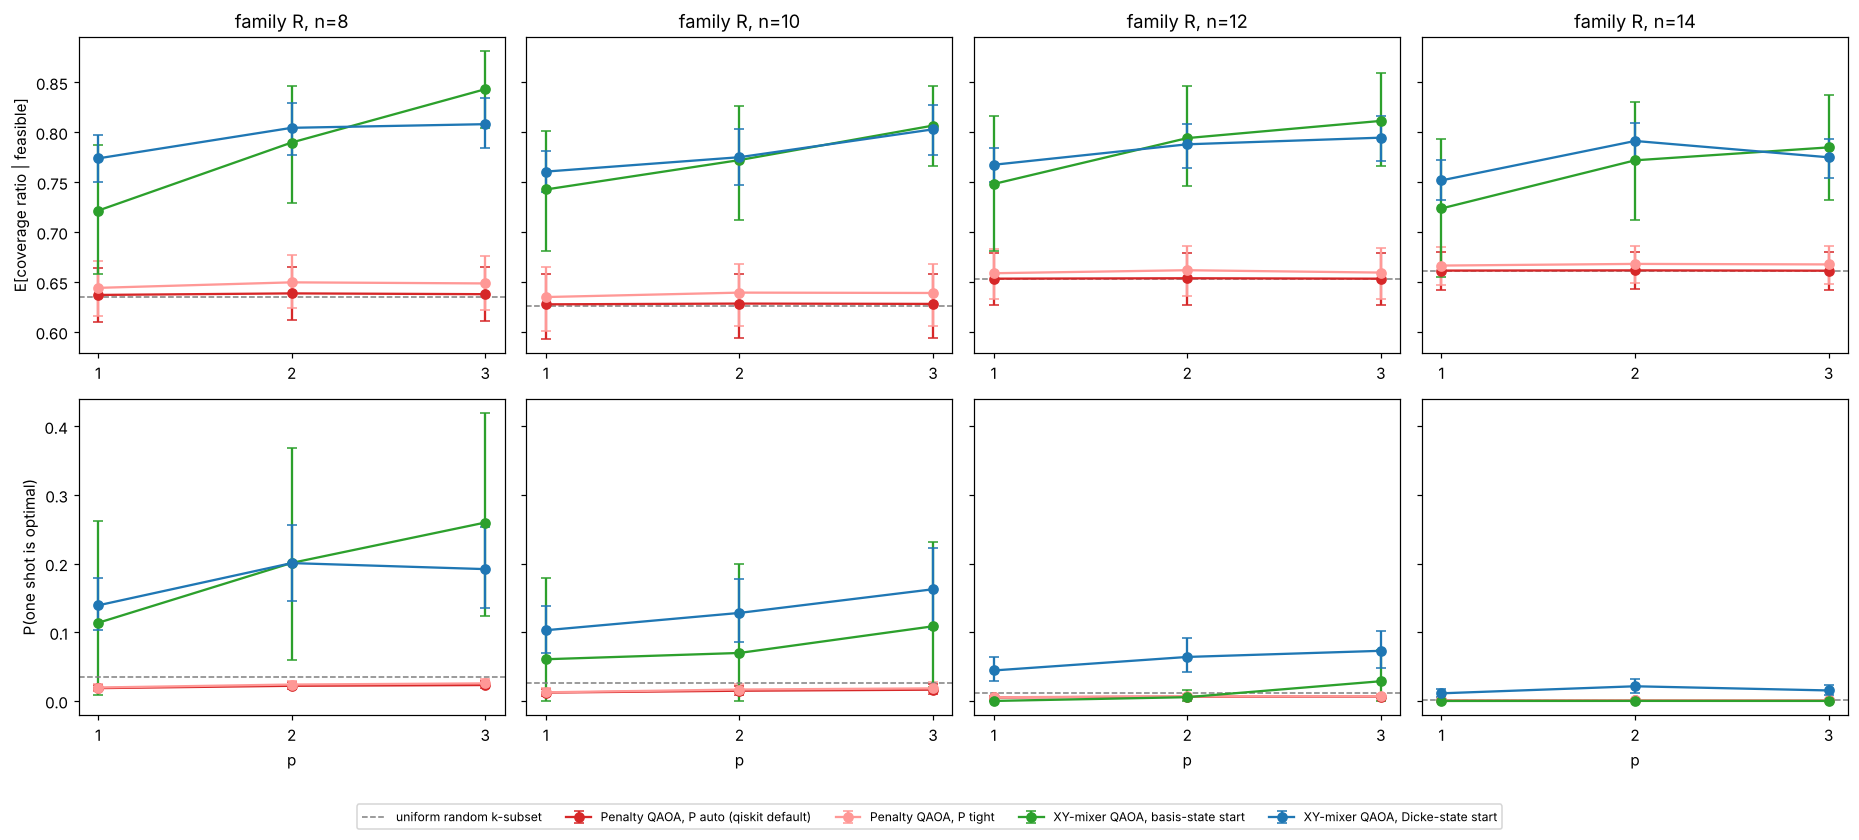

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharey='row')
for col, n_ in enumerate(sorted(ENSEMBLE_SIZES)):
    sub = quality_df[(quality_df.family == 'R') & (quality_df.n == n_)]
    for row, metric in enumerate(['ratio_cond', 'p_opt']):
        ax = axes[row, col]
        for method in METHODS:
            stats = [boot_ci(sub[(sub.method == method) & (sub.p == p)][metric].values, seed=2) for p in P_LIST]
            m_, lo, hi = np.array(stats).T
            ax.errorbar(P_LIST, m_, yerr=[m_ - lo, hi - m_], marker='o', capsize=3, color=METHOD_COLORS[method],
                        label=METHOD_LABELS[method] if col == 0 and row == 0 else None)
        ax.axhline(sub[sub.method == 'random'][metric].mean(), color='gray', ls='--', lw=1,
                   label='uniform random k-subset' if col == 0 and row == 0 else None)
        ax.set_xticks(P_LIST)
        if row == 1:
            ax.set_xlabel('p')
        if row == 0:
            ax.set_title(f'family R, n={n_}')
axes[0, 0].set_ylabel('E[coverage ratio | feasible]')
axes[1, 0].set_ylabel('P(one shot is optimal)')
fig.legend(loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

In [13]:
# Paired comparisons on the same instances (Wilcoxon signed-rank + bootstrap CI of the mean difference)
def paired(df, fam, n_, p, m_a, m_b, metric):
    a = df[(df.family == fam) & (df.n == n_) & (df.method == m_a) & (df.p == p)].set_index('instance')[metric]
    b = df[(df.family == fam) & (df.n == n_) & (df.method == m_b) & (df.p == p)].set_index('instance')[metric]
    diff = (a - b.loc[a.index]).values
    pval = wilcoxon(diff).pvalue if np.any(diff != 0) else 1.0
    return diff, pval


pair_rows = []
for fam, n_ in [('R', 8), ('R', 10), ('R', 12), ('R', 14), ('H', 12)]:
    for p in P_LIST:
        for m_a, m_b in [('native', 'penalty_tight'), ('native_dicke', 'penalty_tight'), ('penalty_tight', 'penalty_auto')]:
            for metric in ['ratio_cond', 'p_opt', 'best_of_10']:
                diff, pval = paired(quality_df, fam, n_, p, m_a, m_b, metric)
                pair_rows.append({'family': fam, 'n': n_, 'p': p, 'comparison': f'{m_a} - {m_b}', 'metric': metric,
                                  'mean_diff [95% CI]': fmt_ci(boot_ci(diff, seed=3)), 'wins': int((diff > 0).sum()),
                                  'losses': int((diff < 0).sum()), 'wilcoxon_p': pval})
pair_df = pd.DataFrame(pair_rows)
pair_df.to_csv(f'{RESULTS_DIR}/quality_paired_tests.csv', index=False)
display(pair_df[(pair_df.metric == 'ratio_cond')].drop(columns='metric').round(4))

,family,n,p,comparison,mean_diff [95% CI],wins,losses,wilcoxon_p
0,R,8,1,native - penalty_tight,"0.077 [0.014, 0.149]",14,6,0.0215
3,R,8,1,native_dicke - penalty_tight,"0.130 [0.111, 0.148]",20,0,0.0000
6,R,8,1,penalty_tight - penalty_auto,"0.007 [0.005, 0.008]",19,1,0.0000
9,R,8,2,native - penalty_tight,"0.140 [0.082, 0.204]",18,2,0.0001
12,R,8,2,native_dicke - penalty_tight,"0.155 [0.136, 0.173]",20,0,0.0000
15,R,8,2,penalty_tight - penalty_auto,"0.011 [0.010, 0.012]",20,0,0.0000
18,R,8,3,native - penalty_tight,"0.195 [0.148, 0.247]",20,0,0.0000
21,R,8,3,native_dicke - penalty_tight,"0.160 [0.143, 0.176]",20,0,0.0000
24,R,8,3,penalty_tight - penalty_auto,"0.011 [0.008, 0.014]",17,3,0.0000
27,R,10,1,native - penalty_tight,"0.108 [0.046, 0.165]",15,5,0.0049


In [14]:
# The metric matters: penalty QAOA's most probable feasible bitstring vs what one shot gives
crit = quality_df[(quality_df.family == 'R') & (quality_df.n == 12)].groupby(['method', 'p'])[
    ['ratio_top1', 'ratio_cond', 'p_feasible', 'best_of_100']].mean().round(3)
display(crit)

ratio_top1  ratio_cond  p_feasible  best_of_100
method        p                                                 
native        1       0.747       0.748       1.000        0.803
              2       0.789       0.794       1.000        0.900
              3       0.814       0.811       1.000        0.907
native_dicke  1       0.928       0.767       1.000        0.992
              2       0.898       0.788       1.000        0.993
              3       0.915       0.795       1.000        0.988
penalty_auto  1       0.991       0.653       0.444        0.941
              2       0.986       0.654       0.536        0.948
              3       0.851       0.653       0.567        0.950
penalty_tight 1       0.991       0.659       0.432        0.943
              2       0.996       0.662       0.521        0.951
              3       0.901       0.659       0.554        0.952
random        0         NaN       0.653       1.000        0.967

**Reading.**

- **Penalty QAOA at $p \le 3$ behaves almost like a uniform sampler.** Its expected ratio
  $E[\text{ratio}\mid\text{feasible}]$ is within 0.015 of the uniformly-random value at every $n$, its
  probability of an optimal shot is *below* that of random subsets, and 35–57% of its shots
  are infeasible. The penalty occupies almost the whole spectrum of the cost operator (for
  $P_\text{auto}$ the penalty coefficients are an order of magnitude larger than the objective's), so
  the few available layers are spent raising the feasible fraction (0.43 at $p=1$ → 0.55 at
  $p=3$ for $n=12$) rather than biasing towards good selections. $P_\text{tight}$ is better on almost
  every instance, but only by 0.005–0.011.
- **The XY mixer is better at every $n$ and $p$**, by 0.05–0.20 in expected ratio. With the Dicke
  start it beats penalty QAOA on every instance; with the basis-state start the gain is larger
  at $p = 3$ but less uniform, and its probability of an optimal shot collapses with $n$ (≈0 at
  $n = 14$): with a few ring layers the amplitude stays within a few hops of the initial
  selection, which is arbitrary (stations $0..k-1$).
- **The metric matters.** The most probable feasible bitstring of penalty QAOA is the optimum on
  most instances (`ratio_top1` ≈ 0.99 at $p = 1, 2$) although a shot from it is no better than
  random: the exact mode of a nearly flat distribution. With finite shots that mode is not
  resolvable. Conversely, best-of-$S$ metrics saturate: with 100–1000 shots, uniformly random
  subsets come within a few percent of the optimum at this size, so they cannot separate methods.
  This is what made penalty QAOA look optimal in the previous version (`MinimumEigenOptimizer`
  returns the best of ~1000 samples).
- **Absolute level.** No QAOA variant here is competitive with greedy (mean ratio ≥ 0.99 on
  family R). On family H, where greedy averages 0.945 and LP top-$k$ 0.928, ten shots of the
  Dicke-start circuit give about 0.957 on average — but randomized LP rounding and simulated
  annealing find the optimum on nearly every H instance.

### The Vienna instance under the same pipeline

Vienna, optimum 21/25; classical: greedy 0.905, LP top-k 1.000, SA 1.000, proxy argmax 1.000


p_feasible  ratio_cond  p_opt  ratio_top1  best_of_1  best_of_10  best_of_100  best_of_1000
method        p                                                                                             
penalty_auto  1       0.445       0.747  0.002       1.000      0.332       0.834        0.927         0.992
              2       0.529       0.747  0.002       1.000      0.395       0.846        0.932         0.994
              3       0.606       0.747  0.002       1.000      0.453       0.854        0.936         0.996
penalty_tight 1       0.443       0.748  0.002       1.000      0.331       0.835        0.928         0.992
              2       0.607       0.750  0.003       1.000      0.455       0.857        0.938         0.997
              3       0.621       0.750  0.003       1.000      0.466       0.858        0.939         0.997
native        1       1.000       0.640  0.000       0.619      0.640       0.723        0.759         0.762
              2       1.000       0.809  0.000       0.810      0.809       0.819        0.852         0.859
              3       1.000       0.856  0.000       0.857      0.856       0.902        0.922         0.957
native_dicke  1       1.000       0.807  0.016       0.905      0.807       0.921        0.990         1.000
              2       1.000       0.819  0.024       0.905      0.819       0.930        0.996         1.000
              3       1.000       0.822  0.032       0.905      0.822       0.933        0.998         1.000
random        0       1.000       0.747  0.004         NaN      0.747       0.878        0.951         0.999

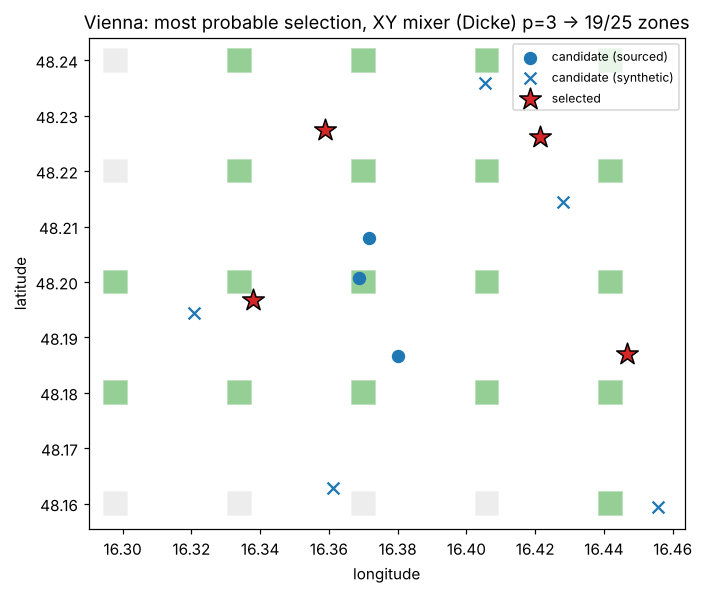

In [15]:
city_rows = []
city_states = {}
for method in METHODS:
    for p in P_LIST:
        th_c, probs_c, _, _, _ = optimise_qaoa(city, method, p, 6, seed=SEED + 11 * p, gamma_scale=GAMMA_SCALE[method], maxiter=MAXITER)
        city_states[(method, p)] = probs_c
        city_rows.append({'method': method, 'p': p, **output_metrics(city, probs_c, SHOTS_LIST)})
city_rows.append({'method': 'random', 'p': 0, **random_metrics(city, SHOTS_LIST)})
city_df = pd.DataFrame(city_rows)
city_df.to_csv(f'{RESULTS_DIR}/vienna_case_study.csv', index=False)
print(f"Vienna, optimum {city.opt}/25; classical: greedy {city_base['greedy']:.3f}, LP top-k {city_base['lp_topk']:.3f}, "
      f"SA {city_base['sim_annealing']:.3f}, proxy argmax {city_base['proxy_exact']:.3f}")
display(city_df.set_index(['method', 'p']).round(3))

# map: most probable feasible selection of the Dicke-start XY mixer at p=3
probs_map = city_states[('native_dicke', 3)]
zf = np.where(city.feas)[0]
sel_map = bits_to_sel(zf[np.argmax(probs_map[zf])], city.n)
covered = cov_city[sel_map].sum(axis=0) > 0
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(zones['lon'], zones['lat'], s=260, marker='s', c=['#2ca02c' if c_ else '#dddddd' for c_ in covered],
           alpha=0.5, edgecolors='white', zorder=1)
mask = ~stations.index.isin(sel_map)
ax.scatter(stations.loc[is_real & mask, 'lon'], stations.loc[is_real & mask, 'lat'], s=60, c='#1f77b4', marker='o', label='candidate (sourced)')
ax.scatter(stations.loc[~is_real & mask, 'lon'], stations.loc[~is_real & mask, 'lat'], s=60, c='#1f77b4', marker='x', label='candidate (synthetic)')
ax.scatter(stations['lon'].iloc[sel_map], stations['lat'].iloc[sel_map], s=220, c='#d62728', marker='*', edgecolors='k', label='selected')
ax.set_title(f"Vienna: most probable selection, XY mixer (Dicke) p=3 -> {true_coverage(sel_map, cov_city)}/{len(zones)} zones")
ax.set_xlabel('longitude'); ax.set_ylabel('latitude'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Result 2 — trainability: variance of exact gradients

**Diagnostic.** For random parameters $\theta$, a barren plateau shows up as
$\mathrm{Var}_\theta[\partial_j E(\theta)]$ shrinking exponentially with $n$ (McClean et al. 2018), or equivalently
as the cost itself concentrating, $\mathrm{Var}_\theta[E(\theta)] \to 0$ exponentially (Arrasmith et al. 2022 show
the two imply each other). Both are measured; **$\mathrm{Var}_\theta[E]$ is the primary one** because it does
not depend on how parameters are scaled, whereas $\partial E/\partial\gamma$ carries a factor of the generator
(see the reading below). What is measured:

- **Exact gradients of all parameters**, by adjoint differentiation (validated against Qiskit's
  `ReverseEstimatorGradient` in Section 3). The previous version used a central finite
  difference with respect to one parameter only. Finite differences add truncation and,
  on hardware, shot-noise amplification ($\propto 1/\epsilon^2$); the parameter-shift rule is exact only
  when each parameter enters through gates $e^{-i\theta P/2}$ with $P^2 = I$. In QAOA one $\gamma$ multiplies a
  whole cost Hamiltonian with many distinct eigenvalue gaps, so its exact shift rule needs many
  shifts (one per distinct frequency); in simulation the adjoint method gives the same exact
  derivative at the cost of about two extra circuit passes. Statistics: $\mathrm{Var}_\theta[E]$ and
  $\overline{\mathrm{Var}} = \frac{1}{P}\sum_j \mathrm{Var}_\theta[\partial_j E]$, each averaged over instances.
- **Sampling over full periods** of the un-rescaled circuit: $\gamma \in [0, 2\pi)$ (all cost
  diagonals are integer, so $e^{-i\gamma C}$ is $2\pi$-periodic), $\beta \in [0,\pi)$ for $e^{-i\beta\sum X}$,
  $\beta \in [0, 2\pi)$ for the XY hops, $\theta \in [0, 2\pi)$ for $R_Y$.
- **Rescaled observable.** The measured cost is $C/\lVert C\rVert_1$, with $\lVert C\rVert_1 = \sum_{S\neq\emptyset}|a_S|$
  its total Pauli weight; then $|E| \le 1$ for every method, so variances are comparable.
  Without it the penalty operator (coefficients $\propto P \approx 40$) would show a variance ~$10^3$–$10^4$ times
  larger purely because of its units. Only the measured observable is rescaled — the circuit
  is unchanged, so the sampled region is still a full period. (Rescaling the operator *inside*
  the circuit while keeping $\gamma\in[0,2\pi)$, as the previous version did, samples only a small region
  near $\gamma = 0$ and changes what is being measured.)

Reference: a hardware-efficient ansatz (`RealAmplitudes`, linear entanglement, reps $= p$)
measuring the same penalty cost. 95% CIs: bootstrap over instances and, within each, over
parameter samples.

In [16]:
TRAIN_KINDS = ['penalty_auto', 'penalty_tight', 'native', 'native_dicke', 'hea']
TRAIN_LABELS = {**METHOD_LABELS, 'hea': 'RealAmplitudes (HEA), penalty cost'}
TRAIN_COLORS = {**METHOD_COLORS, 'hea': '#9467bd'}
SIZE_N, SIZE_P, SIZE_SAMPLES = [6, 8, 10, 12, 14], 2, 200
DEPTH_N, DEPTH_P, DEPTH_SAMPLES = 12, [1, 2, 3, 4, 6, 8], 120
N_TRAIN_INST = 5


def gradient_samples(inst, kind, p, n_samples, seed):
    rng = np.random.default_rng(seed)
    if kind == 'hea':
        d = cost_diag(inst, 'penalty_auto')
        gates, n_par = gates_real_amplitudes(inst.n, p)
        sim, psi0 = Sim(inst.n), first_k_state(inst.n, 0)
        lo, hi = np.zeros(n_par), np.full(n_par, 2 * np.pi)
    else:
        sim, gates, psi0, d = ansatz_for(inst, kind, p)
        n_par = 2 * p
        beta_hi = np.pi if kind.startswith('penalty') else 2 * np.pi
        lo, hi = np.zeros(n_par), np.r_[np.full(p, 2 * np.pi), np.full(p, beta_hi)]
    obs = d / pauli_one_norm(d)
    G = np.empty((n_samples, n_par + 1))           # column 0: energy, columns 1..: gradient
    for s_ in range(n_samples):
        G[s_, 0], G[s_, 1:] = sim.energy_and_grad(psi0, gates, rng.uniform(lo, hi), obs, n_par)
    return G


def _stat(M, which):
    return M[:, 0].var(ddof=1) if which == 'cost' else M[:, 1:].var(axis=0, ddof=1).mean()


def mean_var(G_list, which='grad'):
    """which='cost': Var_theta[E]; which='grad': mean_j Var_theta[dE/dtheta_j] (averaged over instances)."""
    return float(np.mean([_stat(G, which) for G in G_list]))


def boot_mean_var(G_list, which='grad', n_boot=500, seed=0):
    rng = np.random.default_rng(seed)
    reps = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(G_list), len(G_list))
        reps.append(np.mean([_stat(G_list[i][rng.integers(0, len(G_list[i]), len(G_list[i]))], which) for i in pick]))
    return np.array(reps)


train_insts = {n_: [Instance(make_instance(n_, seed=600000 + 100 * n_ + s), round(n_ / 3)) for s in range(N_TRAIN_INST)]
               for n_ in sorted(set(SIZE_N + [DEPTH_N]))}

t0 = time.time()
size_G = {(kind, n_): [gradient_samples(inst_t, kind, SIZE_P, SIZE_SAMPLES, seed=SEED + 31 * i + n_)
                       for i, inst_t in enumerate(train_insts[n_])] for kind in TRAIN_KINDS for n_ in SIZE_N}
print(f"size scan done [{time.time() - t0:.0f}s]")
depth_G = {(kind, p): [gradient_samples(inst_t, kind, p, DEPTH_SAMPLES, seed=SEED + 37 * i + p)
                       for i, inst_t in enumerate(train_insts[DEPTH_N])] for kind in TRAIN_KINDS for p in DEPTH_P}
print(f"depth scan done [{time.time() - t0:.0f}s]")

size scan done [110s]


depth scan done [255s]


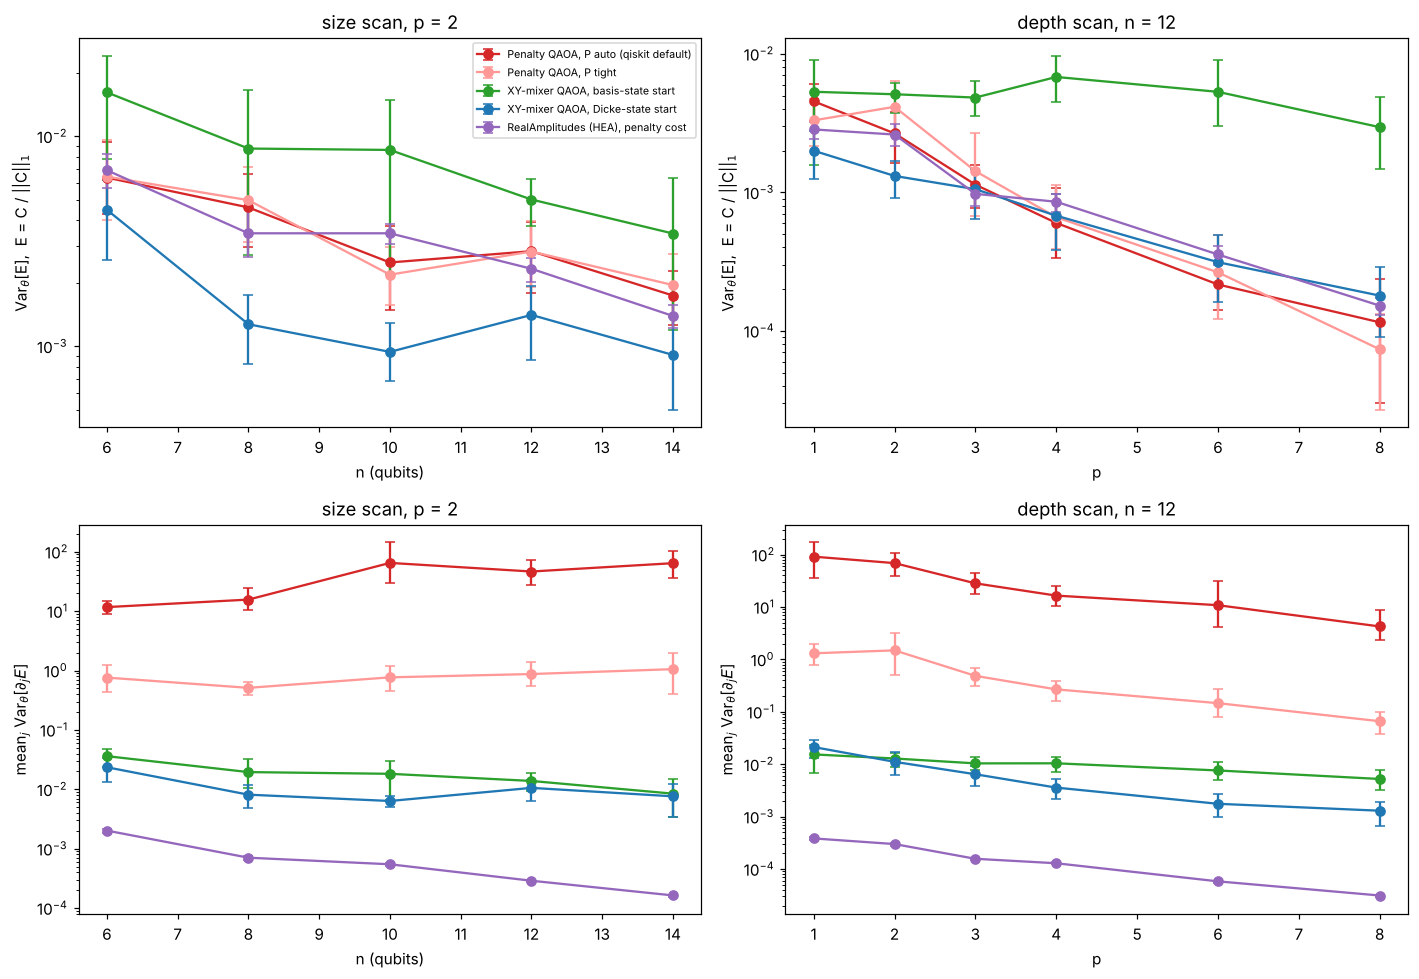

Fitted slope of ln(variance) vs n (p = 2), 95% bootstrap CI:


,statistic,kind,slope_ln_var_per_qubit,ci_lo,ci_hi,var_ratio_n14_over_n6
0,cost,penalty_auto,-0.153,-0.216,-0.087,0.275
1,cost,penalty_tight,-0.147,-0.215,-0.076,0.305
2,cost,native,-0.183,-0.295,-0.080,0.213
3,cost,native_dicke,-0.154,-0.225,-0.087,0.204
4,cost,hea,-0.179,-0.204,-0.149,0.203
5,grad,penalty_auto,0.225,0.147,0.289,5.487
6,grad,penalty_tight,0.059,-0.047,0.151,1.387
7,grad,native,-0.163,-0.252,-0.086,0.234
8,grad,native_dicke,-0.100,-0.196,-0.023,0.324
9,grad,hea,-0.296,-0.306,-0.285,0.081


kind,hea,native,native_dicke,penalty_auto,penalty_tight
p,,,,,
1,2.85e-03,5.32e-03,2.00e-03,4.54e-03,3.31e-03
2,2.61e-03,5.11e-03,1.31e-03,2.67e-03,4.14e-03
3,9.76e-04,4.83e-03,1.05e-03,1.14e-03,1.42e-03
4,8.56e-04,6.81e-03,6.79e-04,6.01e-04,6.61e-04
6,3.56e-04,5.32e-03,3.13e-04,2.16e-04,2.65e-04
8,1.52e-04,2.96e-03,1.80e-04,1.15e-04,7.36e-05


In [17]:
size_rows, slope_rows, depth_rows = [], [], []
for which in ['cost', 'grad']:
    for kind in TRAIN_KINDS:
        boots, points = [], []
        for n_ in SIZE_N:
            b = boot_mean_var(size_G[(kind, n_)], which, seed=n_)
            boots.append(b); points.append(mean_var(size_G[(kind, n_)], which))
            size_rows.append({'statistic': which, 'kind': kind, 'n': n_, 'var': points[-1],
                              'ci_lo': np.quantile(b, 0.025), 'ci_hi': np.quantile(b, 0.975)})
        bslopes = [np.polyfit(SIZE_N, np.log([boots[j][r] for j in range(len(SIZE_N))]), 1)[0] for r in range(len(boots[0]))]
        slope_rows.append({'statistic': which, 'kind': kind, 'slope_ln_var_per_qubit': np.polyfit(SIZE_N, np.log(points), 1)[0],
                           'ci_lo': np.quantile(bslopes, 0.025), 'ci_hi': np.quantile(bslopes, 0.975),
                           'var_ratio_n14_over_n6': points[-1] / points[0]})
        for p in DEPTH_P:
            b = boot_mean_var(depth_G[(kind, p)], which, seed=100 + p)
            depth_rows.append({'statistic': which, 'kind': kind, 'p': p, 'var': mean_var(depth_G[(kind, p)], which),
                               'ci_lo': np.quantile(b, 0.025), 'ci_hi': np.quantile(b, 0.975)})
size_df, slope_df, depth_df = pd.DataFrame(size_rows), pd.DataFrame(slope_rows), pd.DataFrame(depth_rows)
size_df.to_csv(f'{RESULTS_DIR}/variance_size_scan.csv', index=False)
depth_df.to_csv(f'{RESULTS_DIR}/variance_depth_scan.csv', index=False)
slope_df.to_csv(f'{RESULTS_DIR}/variance_slopes.csv', index=False)

YLAB = {'cost': r'Var$_\theta$[E],  E = C / ||C||$_1$', 'grad': r'mean$_j$ Var$_\theta$[$\partial_j E$]'}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, which in enumerate(['cost', 'grad']):
    for kind in TRAIN_KINDS:
        s_ = size_df[(size_df.statistic == which) & (size_df.kind == kind)]
        axes[row, 0].errorbar(s_.n, s_['var'], yerr=[s_['var'] - s_.ci_lo, s_.ci_hi - s_['var']], marker='o', capsize=3,
                              color=TRAIN_COLORS[kind], label=TRAIN_LABELS[kind])
        d_ = depth_df[(depth_df.statistic == which) & (depth_df.kind == kind)]
        axes[row, 1].errorbar(d_.p, d_['var'], yerr=[d_['var'] - d_.ci_lo, d_.ci_hi - d_['var']], marker='o', capsize=3,
                              color=TRAIN_COLORS[kind], label=TRAIN_LABELS[kind])
    for col in range(2):
        axes[row, col].set_yscale('log'); axes[row, col].set_ylabel(YLAB[which])
    axes[row, 0].set_xlabel('n (qubits)'); axes[row, 0].set_title(f'size scan, p = {SIZE_P}')
    axes[row, 1].set_xlabel('p'); axes[row, 1].set_title(f'depth scan, n = {DEPTH_N}')
axes[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()
print('Fitted slope of ln(variance) vs n (p = 2), 95% bootstrap CI:')
display(slope_df.round(3))
display(depth_df[depth_df.statistic == 'cost'].pivot(index='p', columns='kind', values='var').apply(lambda c: c.map(lambda v: f'{v:.2e}')))

**Reading.**

- **Cost concentration (top row).** $\mathrm{Var}_\theta[E]$ decreases with $n$ for every ansatz at a similar
  rate — fitted slopes between about −0.15 and −0.18 per qubit with overlapping 95% CIs — so at
  $n \le 14$, $p = 2$ the data do not separate the encodings. For scale: a unitary 2-design on $n$ qubits
  gives $\mathrm{Var} \propto 2^{-n}$, slope $-\ln 2 \approx -0.69$, and the dimension of the XY mixer's feasible subspace
  $\binom{n}{k}$ grows at a comparable rate over this range. All measured slopes are several times
  smaller: none of these shallow circuits is near a barren plateau at these sizes. The short range
  of $n$ (6–14) allows a descriptive slope, not an asymptotic rate.
- **Depth (top right).** At $n = 12$, $\mathrm{Var}[E]$ falls by one to two orders of magnitude from $p = 1$ to
  $p = 8$ (by factors of 10–45) for penalty QAOA, the Dicke-start XY mixer and the HEA. The basis-start XY mixer stays
  nearly flat, consistent with its amplitude remaining close to the initial state — the same
  mechanism that limits its probability of reaching the optimum in Result 1.
- **Gradients (bottom row).** For the XY mixer and the HEA the gradient variance tells the same
  story. For penalty QAOA it *grows* with $n$ ($P_\text{auto}$) or stays flat ($P_\text{tight}$). This is an
  effect of units, not of trainability: $\partial E/\partial\gamma$ carries a factor of the generator $C$, whose
  spectrum is dominated by $P(\sum_i x_i-k)^2$, and $P$ grows with $n$. The cost variance does not
  depend on how the parameters are scaled, which is why it is the primary diagnostic here;
  exponential cost concentration and exponentially vanishing gradients imply each other
  (Arrasmith et al. 2022), so nothing is lost for the barren-plateau question.
- **Consequence for the research question.** The quality gap of Result 1 is not explained by a
  trainability gap: at these sizes both encodings concentrate similarly and mildly. The
  difference is in where the ansatz can put probability — the penalty circuit spends it on
  feasibility.

## 7. Result 3 — cost on hardware after routing

The idealised (all-to-all) circuit depth is misleading for hardware: the penalty term
$P(\sum_i x_i - k)^2$ contains a $Z_iZ_j$ term for **every** pair, while the ring mixer couples only
neighbours on a ring, which embeds in heavy-hex with few SWAPs. Below, both ansätze are
transpiled (offline, seeded) for the coupling map and native gates of `ibm_marrakesh`
(`FakeMarrakesh`), for several $n$, $p$ and transpiler seeds. Reported: number of two-qubit
gates (CZ), circuit depth, and two-qubit depth. Penalty circuits use $P_\text{tight}$ (the value of $P$
does not change the circuit structure).

240 transpilations [12s]


two_qubit_gates         depth        two_qubit_depth      
                        mean   std    mean    std            mean   std
n  p ansatz                                                            
8  1 native             52.4   1.3   132.8    9.3            35.8   3.6
     penalty           122.6   2.5   236.4   21.5            71.2   7.0
   2 native            112.0   0.0   265.4   13.7            72.4   6.4
     penalty           249.4   4.9   447.8   19.8           136.2   8.3
   3 native            179.4   2.5   409.4   16.6           114.0   7.3
     penalty           378.6   6.8   674.0   52.9           204.8  16.5
10 1 native            133.4   5.4   252.2   10.8            79.4   5.5
     penalty           209.4   3.3   323.4   25.8           100.6   8.6
   2 native            293.8  11.5   543.4   29.0           175.2  14.8
     penalty           423.6  11.1   590.2   45.4           182.8  16.8
   3 native            463.8  14.0   873.6   25.9           281.8  12.8
     penalty           634.2  25.3   860.4   82.3           265.8  24.8
12 1 native            136.8   5.4   250.6    9.4            80.2   2.6
     penalty           310.2  10.9   432.8   31.0           137.4  10.8
   2 native            290.4  14.6   517.4   35.0           167.4  16.0
     penalty           625.2   8.1   753.2   87.1           236.8  27.0
   3 native            454.2  28.4   778.6   76.3           246.4  30.1
     penalty           948.0  26.3  1093.4  140.1           346.4  44.6
14 1 native            205.0   7.9   325.6   38.7           105.8  13.6
     penalty           429.2  19.6   505.6   54.0           159.0  19.1
   2 native            466.4   9.8   687.6   56.0           225.6  17.5
     penalty           875.2  11.7   816.8   42.6           250.6  19.0
   3 native            717.0  17.4  1058.8   59.7           348.4  20.2
     penalty          1327.8  26.5  1327.8  106.1           424.6  38.9

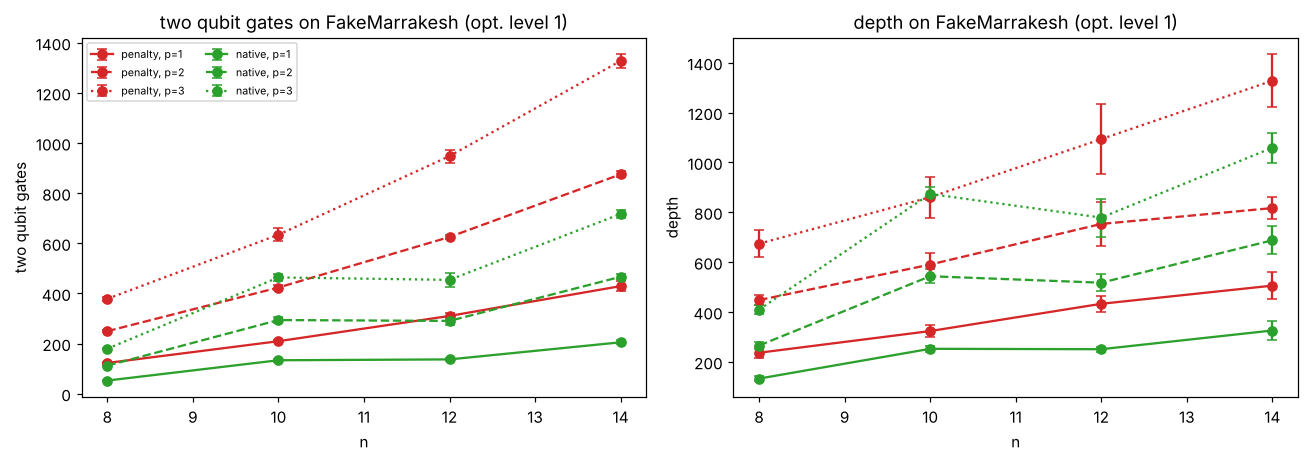

two-qubit gate ratio penalty / native (level 1):


p,1,2,3
n,,,
8,2.34,2.23,2.11
10,1.57,1.44,1.37
12,2.27,2.15,2.09
14,2.09,1.88,1.85


In [18]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

fake_backend = FakeMarrakesh()
TRANSPILE_SEEDS = [0, 1, 2, 3, 4]
COST_N, COST_P = [8, 10, 12, 14], [1, 2, 3]

cost_rows = []
t0 = time.time()
for n_ in COST_N:
    inst_c = Instance(make_instance(n_, seed=1000 * n_), round(n_ / 3))
    op_pen, _, _ = qiskit_penalty_op(inst_c, penalty_tight(inst_c))
    H_C_c, _ = diag_to_sparse_pauli(cost_diag(inst_c, 'native'))
    for p in COST_P:
        circs = {'penalty': QAOAAnsatz(op_pen, reps=p), 'native': qiskit_native_circuit(inst_c, p, H_C_c)}
        for kind, qc in circs.items():
            qc_b = qc.assign_parameters(np.random.default_rng(p).uniform(0, 1, qc.num_parameters))
            qc_b.measure_all()
            for level in [1, 3]:
                for ts in TRANSPILE_SEEDS:
                    isa = generate_preset_pass_manager(backend=fake_backend, optimization_level=level, seed_transpiler=ts).run(qc_b)
                    n2q = sum(1 for ins in isa.data if ins.operation.num_qubits == 2)
                    cost_rows.append({'n': n_, 'p': p, 'ansatz': kind, 'opt_level': level, 'seed': ts, 'two_qubit_gates': n2q,
                                      'depth': isa.depth(), 'two_qubit_depth': isa.depth(lambda ins: ins.operation.num_qubits == 2)})
cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(f'{RESULTS_DIR}/hardware_cost_fakemarrakesh.csv', index=False)
print(f"{len(cost_df)} transpilations [{time.time() - t0:.0f}s]")

cost_tab = cost_df[cost_df.opt_level == 1].groupby(['n', 'p', 'ansatz'])[['two_qubit_gates', 'depth', 'two_qubit_depth']].agg(['mean', 'std']).round(1)
display(cost_tab)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, metric in zip(axes, ['two_qubit_gates', 'depth']):
    for kind, color in [('penalty', '#d62728'), ('native', '#2ca02c')]:
        for p, ls in zip(COST_P, ['-', '--', ':']):
            s_ = cost_df[(cost_df.opt_level == 1) & (cost_df.ansatz == kind) & (cost_df.p == p)].groupby('n')[metric]
            ax.errorbar(COST_N, s_.mean(), yerr=s_.std(), color=color, ls=ls, marker='o', capsize=3, label=f'{kind}, p={p}')
    ax.set_xlabel('n'); ax.set_ylabel(metric.replace('_', ' ')); ax.set_title(f'{metric.replace("_", " ")} on FakeMarrakesh (opt. level 1)')
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

ratio_2q = (cost_df[(cost_df.opt_level == 1) & (cost_df.ansatz == 'penalty')].groupby(['n', 'p'])['two_qubit_gates'].mean()
            / cost_df[(cost_df.opt_level == 1) & (cost_df.ansatz == 'native')].groupby(['n', 'p'])['two_qubit_gates'].mean())
print('two-qubit gate ratio penalty / native (level 1):')
display(ratio_2q.unstack().round(2))

**Reading.** After routing, penalty QAOA needs roughly 1.4–2.3 times the two-qubit gates of
the XY mixer for the same $n$ and $p$ (spread over transpiler seeds is a few percent), and is
deeper in most settings. The ratio depends on the instance through the overlap terms of the
cost layer, which both ansätze share (one instance per $n$ here; the $n = 10$ instance has the
densest overlap graph, 40% of station pairs against 18–26% for the others). In the idealised all-to-all circuits the order is reversed (the XY mixer is two to three
times deeper, Section 8), so a depth comparison before routing points the wrong way. Not counted:
the Dicke-state preparation ($O(kn)$ two-qubit gates), which would reduce the XY mixer's
advantage at $p = 1$.

## 8. The `ibm_marrakesh` run, re-analysed

**What was run (5 October 2026).** One batch job (`db1pramegvvc73bi0du0`, 4000 shots per
circuit) with six circuits — penalty QAOA ($P_\text{auto}$) and XY-mixer QAOA (basis start), $p = 1, 2, 3$
— on instance `make_instance(12, seed=0)`, $k=4$, optimum 13/25. Parameters were optimised
locally (one COBYLA run per circuit), so no optimisation used QPU time.

**What was reported then, and why it was not a fair comparison.** For each circuit the
best true coverage among the 10 most frequent feasible bitstrings (12–13 of 13 for penalty $p=1,2$),
against the *single* most probable bitstring for the simulator. Choosing the best of 10
feasible 4-subsets out of $\binom{12}{4} = 495$ scores well even for random bitstrings.

**Limits of this re-analysis.** The raw counts of that job were not saved (only the summary
printed below), so readout mitigation cannot be applied to them, and there is one job only.
What can be done offline, and is done here: (1) rebuild exactly the same circuits and check
them against the recorded transpiled depths; (2) apply **the same top-10 extraction** to the
noiseless simulator and to a fully depolarised device (uniform bitstrings), with Monte-Carlo
error bars at 4000 shots; (3) a noisy emulation with the device's calibration data, with and
without readout mitigation. If the IBM account used for the run is configured, the next cell
also downloads the raw counts and saves them to `data/`, and the whole analysis below runs on
them as well.

In [19]:
HW_ARCHIVE = {
    'job_id': 'db1pramegvvc73bi0du0', 'backend': 'ibm_marrakesh', 'date': '2026-10-05', 'shots': 4000,
    'instance': 'make_instance(12, seed=0), k=4, lambda=1, 25 zones', 'optimum': 13,
    'circuits': ['penalty_p1', 'native_p1', 'penalty_p2', 'native_p2', 'penalty_p3', 'native_p3'],
    'idealized_depth': {'penalty_p1': 66, 'native_p1': 125, 'penalty_p2': 104, 'native_p2': 249, 'penalty_p3': 142, 'native_p3': 373},
    'simulator_top1_coverage_previous_version_1000_unseeded_shots': {'penalty_p1': 11, 'native_p1': 6, 'penalty_p2': 8, 'native_p2': 8, 'penalty_p3': 7, 'native_p3': 8},
    'isa_depth_live': {'penalty_p1': 550, 'native_p1': 322, 'penalty_p2': 699, 'native_p2': 588, 'penalty_p3': 998, 'native_p3': 903},
    'isa_depth_fakemarrakesh_seed42': {'penalty_p1': 446, 'native_p1': 304, 'penalty_p2': 710, 'native_p2': 587, 'penalty_p3': 958, 'native_p3': 870},
    'best_of_top10_feasible_coverage': {'penalty_p1': 13, 'native_p1': 9, 'penalty_p2': 12, 'native_p2': 10, 'penalty_p3': 11, 'native_p3': 11},
    'all_shots_feasible': {c: False for c in ['penalty_p1', 'native_p1', 'penalty_p2', 'native_p2', 'penalty_p3', 'native_p3']},
    'note': 'Values printed by the notebook at execution time; raw counts were not saved.',
}
os.makedirs('data', exist_ok=True)
with open(f"data/hardware_run_{HW_ARCHIVE['job_id']}.json", 'w') as fh:
    json.dump(HW_ARCHIVE, fh, indent=2)

hw_counts = None      # raw counts, if they can be recovered from IBM
counts_path = f"data/hardware_counts_{HW_ARCHIVE['job_id']}.json"
if os.path.exists(counts_path):
    with open(counts_path) as fh:
        hw_counts = json.load(fh)
    print(f'raw hardware counts loaded from {counts_path}')
else:
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService
        job_result = QiskitRuntimeService().job(HW_ARCHIVE['job_id']).result()
        hw_counts = {lab: pub.data.meas.get_counts() for lab, pub in zip(HW_ARCHIVE['circuits'], job_result)}
        with open(counts_path, 'w') as fh:
            json.dump(hw_counts, fh)
        print(f'raw hardware counts downloaded and saved to {counts_path}')
    except Exception as exc:
        print(f'no IBM Quantum access from this environment ({type(exc).__name__}); using the archived summary only.')
pd.DataFrame({k_: HW_ARCHIVE[k_] for k_ in ['isa_depth_live', 'isa_depth_fakemarrakesh_seed42', 'best_of_top10_feasible_coverage']})

no IBM Quantum access from this environment (AccountNotFoundError); using the archived summary only.


,isa_depth_live,isa_depth_fakemarrakesh_seed42,best_of_top10_feasible_coverage
penalty_p1,550,446,13
native_p1,322,304,9
penalty_p2,699,710,12
native_p2,588,587,10
penalty_p3,998,958,11
native_p3,903,870,11


In [20]:
# Rebuild the six circuits exactly as in the run (code path of that version, kept verbatim where it matters:
# qiskit_algorithms COBYLA, maxiter 150, seeds 1000+p / 2000+p, term order of the native cost operator).
from qiskit_algorithms.optimizers import COBYLA as QK_COBYLA


def build_ising_cost_v1(c, overlap, lam, n):
    terms, const = {}, 0.0
    def add(key, val):
        terms[key] = terms.get(key, 0.0) + val
    def z_key(i):
        p_ = ['I'] * n; p_[n - 1 - i] = 'Z'; return ''.join(p_)
    def zz_key(i, j):
        p_ = ['I'] * n; p_[n - 1 - i] = 'Z'; p_[n - 1 - j] = 'Z'; return ''.join(p_)
    for i in range(n):
        const += c[i] / 2; add(z_key(i), -c[i] / 2)
    for i in range(n):
        for j in range(i + 1, n):
            o = overlap[i, j]
            if o == 0:
                continue
            const += -lam * o / 4
            add(z_key(i), lam * o / 4); add(z_key(j), lam * o / 4); add(zz_key(i, j), -lam * o / 4)
    return SparsePauliOp.from_list([(k_, -v) for k_, v in terms.items()]), -const


def ring_xy_mixer_v1(n):
    terms = []
    for i in range(n):
        j = (i + 1) % n
        for P_ in 'XY':
            s_ = ['I'] * n; s_[n - 1 - i] = P_; s_[n - 1 - j] = P_; terms.append((''.join(s_), 0.5))
    return SparsePauliOp.from_list(terms)


hw_inst = Instance(make_instance(12, seed=0), 4)
assert hw_inst.opt == HW_ARCHIVE['optimum']
op_pen_hw, _, _ = qiskit_penalty_op(hw_inst, None)
op_nat_hw, _ = build_ising_cost_v1(hw_inst.c, hw_inst.O, 1.0, 12)
init_hw = QuantumCircuit(12)
for i in range(4):
    init_hw.x(i)
BASIS_V1 = ['rx', 'ry', 'rz', 'cx', 'x', 'h']
est = StatevectorEstimator()
hw_circuits = {}
t0 = time.time()
for p in [1, 2, 3]:
    for kind, op_, ans_, seed_ in [('penalty', op_pen_hw, QAOAAnsatz(op_pen_hw, reps=p), 1000 + p),
                                   ('native', op_nat_hw, QAOAAnsatz(op_nat_hw, reps=p, initial_state=init_hw, mixer_operator=ring_xy_mixer_v1(12)), 2000 + p)]:
        ans_t = transpile(ans_, basis_gates=BASIS_V1, optimization_level=1)
        f_ = lambda x, a=ans_t, o=op_: est.run([(a, [o], [x])]).result()[0].data.evs[0]
        x0 = np.random.default_rng(seed_).uniform(0, 2 * np.pi, ans_t.num_parameters)
        hw_circuits[f'{kind}_p{p}'] = ans_t.assign_parameters(QK_COBYLA(maxiter=150).minimize(f_, x0=x0).x)
hw_circuits = {lab: hw_circuits[lab] for lab in HW_ARCHIVE['circuits']}
pm42 = generate_preset_pass_manager(backend=fake_backend, optimization_level=1, seed_transpiler=42)
hw_isa = {}
for lab, qc in hw_circuits.items():
    qm = qc.copy(); qm.measure_all()
    hw_isa[lab] = pm42.run(qm)
depth_check = pd.DataFrame({'idealised depth, recorded': HW_ARCHIVE['idealized_depth'],
                            'idealised depth, rebuilt': {lab: qc.depth() for lab, qc in hw_circuits.items()},
                            'ISA depth FakeMarrakesh, recorded': HW_ARCHIVE['isa_depth_fakemarrakesh_seed42'],
                            'ISA depth FakeMarrakesh, rebuilt': {lab: isa.depth() for lab, isa in hw_isa.items()}})
print(f'circuits rebuilt [{time.time() - t0:.0f}s]')
display(depth_check)
same_circuits = bool((depth_check.iloc[:, 0] == depth_check.iloc[:, 1]).all())
print('idealised circuits identical to the ones that were run:', same_circuits)
print('Note: the routed (ISA) depth also depends on the machine: Sabre layout/routing runs one trial per physical CPU '
      f'by default, so the same seed gives different routings on machines with different core counts (this one: {os.cpu_count()} logical CPUs).')

circuits rebuilt [14s]


,"idealised depth, recorded","idealised depth, rebuilt","ISA depth FakeMarrakesh, recorded","ISA depth FakeMarrakesh, rebuilt"
penalty_p1,66,66,446,437
native_p1,125,125,304,300
penalty_p2,104,104,710,757
native_p2,249,249,587,577
penalty_p3,142,142,958,995
native_p3,373,373,870,915


idealised circuits identical to the ones that were run: True
Note: the routed (ISA) depth also depends on the machine: Sabre layout/routing runs one trial per physical CPU by default, so the same seed gives different routings on machines with different core counts (this one: 2 logical CPUs).


In [21]:
# (2) Same top-10 extraction for: hardware (archived), noiseless simulator, fully depolarised device.
def best_of_top10(counts_vec, tc, feas, rng, top=10):
    z = np.where(feas & (counts_vec > 0))[0]
    if z.size == 0:
        return 0
    tie = rng.random(z.size)                     # random tie-breaking among equal counts
    order = z[np.lexsort((tie, -counts_vec[z]))]
    return int(tc[order[:top]].max())


def null_distribution(probs, inst, shots, n_mc, seed):
    rng = np.random.default_rng(seed)
    return np.array([best_of_top10(rng.multinomial(shots, probs), inst.tc, inst.feas, rng) for _ in range(n_mc)])


N_MC = 2000
SHOTS_HW = HW_ARCHIVE['shots']
uniform_probs = np.full(2 ** 12, 1 / 2 ** 12)
null_uniform = null_distribution(uniform_probs, hw_inst, SHOTS_HW, N_MC, seed=SEED)

hw_rows = []
hw_exact_probs = {}
for lab, qc in hw_circuits.items():
    probs = Statevector(qc).probabilities()
    hw_exact_probs[lab] = probs
    sim_dist = null_distribution(probs, hw_inst, SHOTS_HW, N_MC // 2, seed=SEED + len(hw_rows))
    obs_hw = HW_ARCHIVE['best_of_top10_feasible_coverage'][lab]
    m = output_metrics(hw_inst, probs)
    hw_rows.append({'circuit': lab, 'hardware best-of-top10 (archived)': obs_hw,
                    'simulator best-of-top10 (mean)': sim_dist.mean(),
                    'simulator 95% range': f'[{np.quantile(sim_dist, .025):.0f}, {np.quantile(sim_dist, .975):.0f}]',
                    'uniform-noise best-of-top10 (mean)': null_uniform.mean(),
                    'uniform 95% range': f'[{np.quantile(null_uniform, .025):.0f}, {np.quantile(null_uniform, .975):.0f}]',
                    'P(uniform >= hardware)': float((null_uniform >= obs_hw).mean()),
                    'simulator top-1 (exact)': int(round(m['ratio_top1'] * hw_inst.opt)),
                    'simulator top-1 (previous version, 1000 shots)': HW_ARCHIVE['simulator_top1_coverage_previous_version_1000_unseeded_shots'][lab],
                    'simulator p_feasible': m['p_feasible'], 'simulator E[ratio|feasible]': m['ratio_cond']})
hw_df = pd.DataFrame(hw_rows).set_index('circuit')
hw_df.to_csv(f'{RESULTS_DIR}/hardware_reanalysis.csv')
display(hw_df.round(3))
print(f"uniform bitstrings: P(feasible) = {hw_inst.feas.mean():.3f}; E[ratio | feasible] = {hw_inst.random_mean_ratio:.3f}")

,hardware best-of-top10 (archived),simulator best-of-top10 (mean),simulator 95% range,uniform-noise best-of-top10 (mean),uniform 95% range,P(uniform >= hardware),simulator top-1 (exact),"simulator top-1 (previous version, 1000 shots)",simulator p_feasible,simulator E[ratio|feasible]
circuit,,,,,,,,,,
penalty_p1,13,12.267,"[11, 13]",11.474,"[10, 13]",0.116,11,11,0.204,0.743
native_p1,9,6.000,"[6, 6]",11.474,"[10, 13]",1.000,6,6,1.000,0.462
penalty_p2,12,10.926,"[8, 12]",11.474,"[10, 13]",0.498,8,8,0.097,0.628
native_p2,10,8.000,"[8, 8]",11.474,"[10, 13]",0.988,8,8,1.000,0.615
penalty_p3,11,11.334,"[11, 12]",11.474,"[10, 13]",0.874,10,7,0.254,0.694
native_p3,11,11.774,"[10, 12]",11.474,"[10, 13]",0.874,8,8,1.000,0.615


uniform bitstrings: P(feasible) = 0.121; E[ratio | feasible] = 0.648


In [22]:
# (3) Noisy emulation with FakeMarrakesh's calibration (Aer), and tensored readout mitigation.
RUN_NOISY_EMULATION = True
EMU_SHOTS = 1000


def counts_to_vector(counts, n):
    v = np.zeros(2 ** n)
    for bs, c_ in counts.items():
        v[int(bs.replace(' ', ''), 2)] += c_
    return v


def readout_mitigate(vec, phys_qubits, props):
    """Tensored readout mitigation: invert each measured qubit's 2x2 assignment matrix
    A = [[P(0|0), P(0|1)], [P(1|0), P(1|1)]], from the backend's calibration data. Returns a
    quasi-probability vector (it can have small negative entries)."""
    n = len(phys_qubits)
    t = (vec / vec.sum()).reshape([2] * n)
    for clbit, q in enumerate(phys_qubits):
        p10 = props.qubit_property(q, 'prob_meas1_prep0')[0]
        p01 = props.qubit_property(q, 'prob_meas0_prep1')[0]
        A_inv = np.linalg.inv(np.array([[1 - p10, p01], [p10, 1 - p01]]))
        ax = n - 1 - clbit
        t = np.moveaxis(np.tensordot(A_inv, t, axes=([1], [ax])), 0, ax)
    return t.reshape(2 ** n)


def analyse_counts(vec, inst, rng, mitigated=None):
    feas_frac = vec[inst.feas].sum() / vec.sum()
    vf = vec[inst.feas]
    out = {'p_feasible': feas_frac, 'E[ratio|feasible]': float((vf * inst.tc[inst.feas]).sum() / vf.sum() / inst.opt),
           'best_of_top10': best_of_top10(vec, inst.tc, inst.feas, rng)}
    if mitigated is not None:
        mf = np.clip(mitigated, 0, None)
        out['p_feasible (mitigated)'] = float(mf[inst.feas].sum() / mf.sum())
        out['E[ratio|feasible] (mitigated)'] = float((mf[inst.feas] * inst.tc[inst.feas]).sum() / mf[inst.feas].sum() / inst.opt)
    return out


emu_rows = []
if RUN_NOISY_EMULATION:
    from qiskit_aer import AerSimulator
    aer = AerSimulator.from_backend(fake_backend)
    props = fake_backend.properties()
    t0 = time.time()
    rng_emu = np.random.default_rng(SEED)
    for i, (lab, isa) in enumerate(hw_isa.items()):
        counts = aer.run(isa, shots=EMU_SHOTS, seed_simulator=SEED + i).result().get_counts()
        vec = counts_to_vector(counts, 12)
        mit = readout_mitigate(vec, isa.layout.final_index_layout(), props)
        # bootstrap over shots for the feasibility rate
        boot = rng_emu.multinomial(EMU_SHOTS, vec / vec.sum(), size=500)[:, hw_inst.feas].sum(axis=1) / EMU_SHOTS
        emu_rows.append({'circuit': lab, **analyse_counts(vec, hw_inst, rng_emu, mit),
                         'p_feasible 95% CI': f'[{np.quantile(boot, .025):.3f}, {np.quantile(boot, .975):.3f}]'})
        print(f'{lab} emulated [{time.time() - t0:.0f}s]')
    emu_df = pd.DataFrame(emu_rows).set_index('circuit')
    null_uniform_1000 = null_distribution(uniform_probs, hw_inst, EMU_SHOTS, N_MC, seed=SEED + 1)
    emu_df.to_csv(f'{RESULTS_DIR}/hardware_noisy_emulation.csv')
    display(emu_df.round(3))
    print(f"reference, uniform bitstrings: p_feasible = {hw_inst.feas.mean():.3f}, E[ratio|feasible] = {hw_inst.random_mean_ratio:.3f}, "
          f"best_of_top10 at {EMU_SHOTS} shots = {null_uniform_1000.mean():.2f} "
          f"[{np.quantile(null_uniform_1000, .025):.0f}, {np.quantile(null_uniform_1000, .975):.0f}]")

if hw_counts is not None:      # only when the real raw counts are available
    rng_hw = np.random.default_rng(SEED)
    real_rows = []
    for lab, isa in hw_isa.items():
        vec = counts_to_vector(hw_counts[lab], 12)
        real_rows.append({'circuit': lab, **analyse_counts(vec, hw_inst, rng_hw, readout_mitigate(vec, isa.layout.final_index_layout(), fake_backend.properties()))})
    display(pd.DataFrame(real_rows).set_index('circuit').round(3))

penalty_p1 emulated [29s]


native_p1 emulated [41s]


penalty_p2 emulated [95s]


native_p2 emulated [117s]


penalty_p3 emulated [197s]


native_p3 emulated [229s]


,p_feasible,E[ratio|feasible],best_of_top10,p_feasible (mitigated),E[ratio|feasible] (mitigated),p_feasible 95% CI
circuit,,,,,,
penalty_p1,0.187,0.736,12,0.184,0.736,"[0.162, 0.209]"
native_p1,0.765,0.458,8,0.825,0.458,"[0.737, 0.790]"
penalty_p2,0.127,0.623,11,0.126,0.623,"[0.106, 0.147]"
native_p2,0.604,0.603,10,0.652,0.604,"[0.574, 0.637]"
penalty_p3,0.212,0.695,11,0.210,0.695,"[0.189, 0.237]"
native_p3,0.427,0.614,12,0.434,0.614,"[0.398, 0.460]"


reference, uniform bitstrings: p_feasible = 0.121, E[ratio|feasible] = 0.648, best_of_top10 at 1000 shots = 11.44 [10, 13]


**Reading.**

- *Same circuits.* The idealised depths of the rebuilt circuits equal the recorded ones, and
  the exact simulator's top-1 coverage agrees with the previous version's shot-based value on 5
  of 6 circuits (the sixth, penalty $p=3$, has a flat distribution, so 1000 shots could not
  resolve its mode). The routed depths differ by a few percent because Sabre's default number
  of trials equals the number of CPU cores.
- *The statistic carries no signal.* Uniformly random 12-bit strings, put through the same
  "best of the 10 most frequent feasible bitstrings" extraction at 4000 shots, score about 11.5/13
  on average (95% range 10–13). Every hardware value lies within or below that range; the
  largest, 13/13 for penalty $p = 1$, is reached by uniform noise in about 12% of trials. The
  XY-mixer values for $p = 1$ (9, below the range) and $p = 2$ (10, at its lower edge) come from
  circuits whose noiseless output is concentrated on poor selections (6 and 8/13): noise moved
  them towards uniform.
- *The circuits were weak to begin with.* With one COBYLA run each and the basis-state start,
  the noiseless XY circuits have $E[\text{ratio}\mid\text{feasible}]$ = 0.46–0.62, below random (0.65). A
  perfect device would not have shown an advantage either; Results 1–3 use better-optimised
  circuits.
- *Noisy emulation.* With the device's calibration data the XY circuits keep 76.5%, 60.4% and 42.7% of
  shots feasible at $p = 1, 2, 3$ (uniform: 12%), so they are not fully depolarised, and the
  quality of their feasible shots tracks the noiseless values. Readout mitigation changes the
  feasible fraction by at most 6 percentage points and the coverage ratio by less than 0.01: gate
  errors, not readout, dominate at several hundred two-qubit gates.

**For the next hardware run** (not executed here: it needs an IBM Quantum account and uses
QPU time). Compared with the October run it saves the raw counts, uses the instance and
circuits of Result 1–3 (penalty with $P_\text{tight}$, XY mixer), repeats each circuit in
`N_REPEATS` independent jobs for error bars, adds one uniform-superposition circuit as an
on-device null model, and measures the readout assignment matrices in the same batch
(all-0 and all-1 preparations) instead of relying on the published calibration.

In [23]:
RUN_ON_HARDWARE = False     # set True deliberately; uses QPU time
N_REPEATS, SHOTS_NEXT, BACKEND_ID = 3, 4000, 'ibm_marrakesh'

if RUN_ON_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2
    service = QiskitRuntimeService()
    backend = service.backend(BACKEND_ID)
    pm_hw = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=SEED)
    next_inst = Instance(make_instance(12, seed=0), 4)
    circuits_next = {}
    for p in [1, 2]:
        for method in ['penalty_tight', 'native']:
            th_n, _, _, _, _ = optimise_qaoa(next_inst, method, p, N_RESTARTS, seed=SEED + p, gamma_scale=GAMMA_SCALE[method], maxiter=MAXITER)
            if method == 'native':
                H_C_n, _ = diag_to_sparse_pauli(cost_diag(next_inst, 'native'))
                qc_n = qiskit_native_circuit(next_inst, p, H_C_n).assign_parameters(np.r_[th_n[p:], th_n[:p]])
            else:
                op_n, _, _ = qiskit_penalty_op(next_inst, penalty_tight(next_inst))
                qc_n = QAOAAnsatz(op_n, reps=p).assign_parameters(np.r_[th_n[p:], th_n[:p]])
            circuits_next[f'{method}_p{p}'] = qc_n
    plus = QuantumCircuit(12); plus.h(range(12)); circuits_next['uniform_null'] = plus
    zero = QuantumCircuit(12); circuits_next['readout_cal_0'] = zero
    one = QuantumCircuit(12); one.x(range(12)); circuits_next['readout_cal_1'] = one
    labels_next = list(circuits_next)
    isa_next = []
    for lab in labels_next:
        qm = circuits_next[lab].copy(); qm.measure_all(); isa_next.append(pm_hw.run(qm))
    all_counts = []
    with Batch(backend=backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs = [sampler.run(isa_next, shots=SHOTS_NEXT) for _ in range(N_REPEATS)]
        for r_, job in enumerate(jobs):
            res = job.result()
            all_counts.append({'job_id': job.job_id(), 'counts': {lab: pub.data.meas.get_counts() for lab, pub in zip(labels_next, res)}})
    with open(f'data/hardware_counts_next_{time.strftime("%Y%m%d")}.json', 'w') as fh:
        json.dump(all_counts, fh)
    print('saved; analyse with analyse_counts() exactly as above')
else:
    print('RUN_ON_HARDWARE = False: nothing submitted.')

RUN_ON_HARDWARE = False: nothing submitted.


## 9. Summary (computed from this run)

Every number below is read from variables computed above; `results/summary.json` stores them.
The last cell checks that the numbers quoted in the abstract are the ones computed here.

In [24]:
def q_mean(fam, n_, method, p, metric):
    s_ = quality_df[(quality_df.family == fam) & (quality_df.n == n_) & (quality_df.method == method) & (quality_df.p == p)]
    return boot_ci(s_[metric].values, seed=7)


summary = {
    'run_seconds': round(time.time() - RUN_STARTED),
    'n_instances': {'R': int(sum(f == 'R' for f, _ in ensemble)), 'H': int(sum(f == 'H' for f, _ in ensemble))},
    'qubo_proxy_exact_rate_lambda1': proxy_exact_rate,
    'hard_family_acceptance_rate': N_HARD / hard_scan,
    'greedy_fail_rate_R': base_df[base_df.family == 'R'].groupby('n')['greedy'].apply(lambda x: float(np.mean(x < 1))).to_dict(),
    'quality': {}, 'gradvar_slope': {}, 'two_qubit_gate_ratio_penalty_over_native': {},
    'hardware': {},
}
for fam, n_ in [('R', 8), ('R', 10), ('R', 12), ('R', 14), ('H', 12)]:
    for method in METHODS:
        for p in P_LIST:
            for metric in ['ratio_cond', 'p_opt', 'p_feasible', 'best_of_10', 'best_of_1000', 'ratio_top1']:
                summary['quality'][f'{fam}|n={n_}|{method}|p={p}|{metric}'] = q_mean(fam, n_, method, p, metric)
    for metric in ['ratio_cond', 'p_opt', 'best_of_10', 'best_of_1000']:
        summary['quality'][f'{fam}|n={n_}|random|p=0|{metric}'] = q_mean(fam, n_, 'random', 0, metric)
for _, r in slope_df.iterrows():
    summary['gradvar_slope'][f'{r.statistic}|{r.kind}'] = (float(r.slope_ln_var_per_qubit), float(r.ci_lo), float(r.ci_hi))
for (n_, p), v in ratio_2q.items():
    summary['two_qubit_gate_ratio_penalty_over_native'][f'n={n_}|p={p}'] = float(v)
summary['hardware'] = {lab: {'observed': int(r['hardware best-of-top10 (archived)']),
                             'uniform_null_mean': float(r['uniform-noise best-of-top10 (mean)']),
                             'uniform_null_q025': float(np.quantile(null_uniform, 0.025)),
                             'uniform_null_q975': float(np.quantile(null_uniform, 0.975)),
                             'P_uniform_ge_observed': float(r['P(uniform >= hardware)'])} for lab, r in hw_df.iterrows()}
if emu_rows:
    summary['emulation_p_feasible'] = {lab: float(v) for lab, v in emu_df['p_feasible'].items()}
summary['uniform_p_feasible'] = float(hw_inst.feas.mean())
with open(f'{RESULTS_DIR}/summary.json', 'w') as fh:
    json.dump(summary, fh, indent=1, default=float)

g = lambda key: summary['quality'][key]
rows = []
for fam, n_ in [('R', 12), ('R', 14), ('H', 12)]:
    for method in ['random'] + METHODS:
        for p in ([0] if method == 'random' else [1, 3]):
            rows.append({'set': f'{fam}, n={n_}', 'method': method, 'p': p,
                         'E[ratio|feasible]': fmt_ci(g(f'{fam}|n={n_}|{method}|p={p}|ratio_cond')),
                         'P(optimal shot)': fmt_ci(g(f'{fam}|n={n_}|{method}|p={p}|p_opt')),
                         'best of 10 shots': fmt_ci(g(f'{fam}|n={n_}|{method}|p={p}|best_of_10'))})
summary_table = pd.DataFrame(rows).set_index(['set', 'method', 'p'])
summary_table.to_csv(f'{RESULTS_DIR}/summary_table.csv')
display(summary_table)
print('slope d ln Var / dn (95% CI):', {k_: tuple(round(x, 3) for x in v) for k_, v in summary['gradvar_slope'].items()})
print('two-qubit gates, penalty / native, n=12:', {k_: round(v, 2) for k_, v in summary['two_qubit_gate_ratio_penalty_over_native'].items() if k_.startswith('n=12')})
print(f"total run time so far: {summary['run_seconds'] / 60:.1f} min")

E[ratio|feasible]       P(optimal shot)      best of 10 shots
set     method        p                                                                  
R, n=12 random        0  0.653 [0.626, 0.678]  0.011 [0.007, 0.016]  0.869 [0.852, 0.885]
        penalty_auto  1  0.653 [0.627, 0.679]  0.005 [0.003, 0.007]  0.802 [0.780, 0.821]
                      3  0.653 [0.627, 0.679]  0.006 [0.004, 0.009]  0.826 [0.806, 0.844]
        penalty_tight 1  0.659 [0.633, 0.684]  0.005 [0.003, 0.008]  0.803 [0.782, 0.823]
                      3  0.659 [0.633, 0.685]  0.007 [0.004, 0.010]  0.828 [0.807, 0.847]
        native        1  0.748 [0.677, 0.820]  0.000 [0.000, 0.000]  0.793 [0.721, 0.858]
                      3  0.811 [0.761, 0.859]  0.029 [0.000, 0.075]  0.880 [0.848, 0.911]
        native_dicke  1  0.767 [0.749, 0.785]  0.044 [0.028, 0.064]  0.937 [0.925, 0.948]
                      3  0.795 [0.771, 0.816]  0.073 [0.047, 0.102]  0.951 [0.936, 0.965]
R, n=14 random        0  0.661 [0.641, 0.679]  0.002 [0.001, 0.002]  0.846 [0.837, 0.855]
        penalty_auto  1  0.661 [0.642, 0.679]  0.001 [0.001, 0.001]  0.785 [0.773, 0.795]
                      3  0.661 [0.642, 0.679]  0.001 [0.001, 0.001]  0.804 [0.795, 0.814]
        penalty_tight 1  0.666 [0.647, 0.684]  0.001 [0.001, 0.001]  0.786 [0.775, 0.796]
                      3  0.668 [0.649, 0.685]  0.001 [0.001, 0.002]  0.810 [0.800, 0.819]
        native        1  0.724 [0.651, 0.797]  0.000 [0.000, 0.000]  0.767 [0.693, 0.837]
                      3  0.785 [0.729, 0.838]  0.000 [0.000, 0.000]  0.832 [0.793, 0.869]
        native_dicke  1  0.752 [0.732, 0.772]  0.011 [0.006, 0.017]  0.908 [0.890, 0.924]
                      3  0.775 [0.754, 0.795]  0.015 [0.009, 0.022]  0.921 [0.904, 0.936]
H, n=12 random        0  0.726 [0.708, 0.746]  0.010 [0.007, 0.016]  0.909 [0.899, 0.918]
        penalty_auto  1  0.727 [0.709, 0.746]  0.005 [0.003, 0.007]  0.854 [0.843, 0.865]
                      3  0.727 [0.709, 0.746]  0.006 [0.004, 0.008]  0.873 [0.863, 0.883]
        penalty_tight 1  0.731 [0.714, 0.750]  0.005 [0.003, 0.007]  0.855 [0.844, 0.866]
                      3  0.734 [0.717, 0.752]  0.006 [0.004, 0.009]  0.878 [0.868, 0.888]
        native        1  0.785 [0.716, 0.849]  0.000 [0.000, 0.000]  0.806 [0.750, 0.863]
                      3  0.837 [0.799, 0.872]  0.014 [0.000, 0.041]  0.876 [0.844, 0.909]
        native_dicke  1  0.815 [0.800, 0.829]  0.038 [0.027, 0.052]  0.952 [0.944, 0.961]
                      3  0.826 [0.804, 0.847]  0.042 [0.028, 0.057]  0.957 [0.950, 0.965]

slope d ln Var / dn (95% CI): {'cost|penalty_auto': (-0.153, -0.216, -0.087), 'cost|penalty_tight': (-0.147, -0.215, -0.076), 'cost|native': (-0.183, -0.295, -0.08), 'cost|native_dicke': (-0.154, -0.225, -0.087), 'cost|hea': (-0.179, -0.204, -0.149), 'grad|penalty_auto': (0.225, 0.147, 0.289), 'grad|penalty_tight': (0.059, -0.047, 0.151), 'grad|native': (-0.163, -0.252, -0.086), 'grad|native_dicke': (-0.1, -0.196, -0.023), 'grad|hea': (-0.296, -0.306, -0.285)}
two-qubit gates, penalty / native, n=12: {'n=12|p=1': 2.27, 'n=12|p=2': 2.15, 'n=12|p=3': 2.09}
total run time so far: 38.6 min


In [25]:
# Abstract numbers, generated from the computed summary. The abstract cell at the top of the
# notebook must contain exactly this text; the check below fails otherwise.
def ci_txt(t, d=2):
    return f'{t[0]:.{d}f} [{t[1]:.{d}f}, {t[2]:.{d}f}]'


def abstract_text():
    R12 = lambda m, p, met: g(f'R|n=12|{m}|p={p}|{met}')
    H12 = lambda m, p, met: g(f'H|n=12|{m}|p={p}|{met}')
    sl = lambda kind: summary['gradvar_slope'][f'cost|{kind}']
    r2q = summary['two_qubit_gate_ratio_penalty_over_native']
    hw = summary['hardware']
    emu_nat = [summary['emulation_p_feasible'][f'native_p{p}'] for p in [1, 2, 3]]
    rc = pair_df[pair_df.metric == 'ratio_cond']
    dk = rc[rc.comparison == 'native_dicke - penalty_tight']
    dicke_wins, dicke_total = int(dk.wins.sum()), int((dk.wins + dk.losses).sum())
    bs = rc[rc.comparison == 'native - penalty_tight']
    basis_sig, basis_tot = int((bs.wilcoxon_p < 0.05).sum()), len(bs)
    basis_mean_better = sum(paired(quality_df, r_.family, r_.n, r_.p, 'native', 'penalty_tight', 'ratio_cond')[0].mean() > 0 for r_ in bs.itertuples())
    better_txt = 'in every setting' if basis_mean_better == basis_tot else f'in {basis_mean_better} of {basis_tot} settings'
    lines = [
        f"- **Quality (family R, n = 12, p = 3; mean [95% CI] over 20 instances).** Expected true-coverage ratio of a feasible shot: "
        f"XY mixer {ci_txt(R12('native', 3, 'ratio_cond'))} (basis-state start) and {ci_txt(R12('native_dicke', 3, 'ratio_cond'))} (Dicke start); "
        f"penalty QAOA {ci_txt(R12('penalty_tight', 3, 'ratio_cond'))} with $P_\\text{{tight}}$ and {ci_txt(R12('penalty_auto', 3, 'ratio_cond'))} "
        f"with qiskit's default $P$; uniformly random $k$-subsets {ci_txt(R12('random', 0, 'ratio_cond'))}. Probability that one shot is optimal: "
        f"{R12('native_dicke', 3, 'p_opt')[0]:.3f} (XY, Dicke), {R12('penalty_tight', 3, 'p_opt')[0]:.3f} (penalty), "
        f"{R12('random', 0, 'p_opt')[0]:.3f} (random). Penalty QAOA also wastes {1 - R12('penalty_tight', 3, 'p_feasible')[0]:.0%} of its shots on infeasible strings. "
        f"Across all sizes (n = 8–14) and depths (p = 1–3), the Dicke-start XY mixer beats penalty QAOA on {dicke_wins} of {dicke_total} paired instance comparisons; "
        f"the basis-start version is better on average {better_txt} and significantly so (Wilcoxon p < 0.05) in {basis_sig} of {basis_tot}.",
        f"- **Classically hard instances (family H, n = 12, p = 3)**, where greedy and LP rounding both miss the optimum: XY mixer (Dicke) "
        f"{ci_txt(H12('native_dicke', 3, 'ratio_cond'))}, penalty {ci_txt(H12('penalty_tight', 3, 'ratio_cond'))}, random {ci_txt(H12('random', 0, 'ratio_cond'))}.",
        f"- **The previous version's metrics hid this.** Scored by the best of ~1000 shots (what `MinimumEigenOptimizer` returns), uniformly random "
        f"subsets already reach {R12('random', 0, 'best_of_1000')[0]:.3f} and penalty QAOA {R12('penalty_tight', 3, 'best_of_1000')[0]:.3f}; scored by its single most "
        f"probable bitstring, penalty QAOA looks near-optimal ({R12('penalty_tight', 1, 'ratio_top1')[0]:.2f} at p = 1) although its output is barely biased away from uniform.",
        f"- **Trainability.** Slope of ln Var$_\\theta$[E] per qubit (n = 6–14, p = 2, 95% CI): penalty {sl('penalty_tight')[0]:.2f} "
        f"[{sl('penalty_tight')[1]:.2f}, {sl('penalty_tight')[2]:.2f}], XY mixer {sl('native')[0]:.2f} [{sl('native')[1]:.2f}, {sl('native')[2]:.2f}] (basis) and "
        f"{sl('native_dicke')[0]:.2f} [{sl('native_dicke')[1]:.2f}, {sl('native_dicke')[2]:.2f}] (Dicke), hardware-efficient ansatz {sl('hea')[0]:.2f} "
        f"[{sl('hea')[1]:.2f}, {sl('hea')[2]:.2f}]: overlapping intervals, all far from the $-\\ln 2 \\approx -0.69$ of a unitary 2-design. No difference in cost "
        f"concentration between the encodings is detectable at these sizes, so it does not explain the quality gap. The range of n is short; these are descriptive slopes, not asymptotic rates.",
        f"- **Hardware cost.** After routing to `ibm_marrakesh`'s heavy-hex coupling map, penalty QAOA needs {r2q['n=12|p=1']:.1f}× (p = 1) to "
        f"{r2q['n=12|p=3']:.1f}× (p = 3) the two-qubit gates of the XY mixer at n = 12, although its idealised all-to-all circuit is shallower.",
        f"- **The October hardware run is not evidence either way.** The statistic it reported (best of the 10 most frequent feasible bitstrings) "
        f"averages {hw['penalty_p1']['uniform_null_mean']:.1f}/13 for uniformly random bitstrings (95% range {hw['penalty_p1']['uniform_null_q025']:.0f}–"
        f"{hw['penalty_p1']['uniform_null_q975']:.0f}); the observed values, {min(v['observed'] for v in hw.values())}–{max(v['observed'] for v in hw.values())}/13, "
        f"are within or below that range. A noisy emulation with the device calibration keeps {min(emu_nat):.0%}–{max(emu_nat):.0%} of XY-mixer shots feasible "
        f"(uniform: {summary['uniform_p_feasible']:.0%}), so the circuits are not fully depolarised, but that statistic cannot separate them from noise.",
    ]
    return '\n'.join(lines)


ABSTRACT = abstract_text()
print(ABSTRACT)
nb_path = 'quantum_sensor_placement.ipynb'
if os.path.exists(nb_path):
    with open(nb_path, encoding='utf-8') as fh:
        nb_text = ''.join(json.load(fh)['cells'][0]['source'])
    if '<!--' + 'ABSTRACT_RESULTS-->' in nb_text:
        print('\n[abstract placeholder not yet filled]')
    else:
        assert ABSTRACT in nb_text, 'the abstract does not match the numbers computed in this run'
        print('\nabstract check: the numbers quoted in the abstract match this run.')

- **Quality (family R, n = 12, p = 3; mean [95% CI] over 20 instances).** Expected true-coverage ratio of a feasible shot: XY mixer 0.81 [0.76, 0.86] (basis-state start) and 0.79 [0.77, 0.82] (Dicke start); penalty QAOA 0.66 [0.63, 0.68] with $P_\text{tight}$ and 0.65 [0.63, 0.68] with qiskit's default $P$; uniformly random $k$-subsets 0.65 [0.63, 0.68]. Probability that one shot is optimal: 0.073 (XY, Dicke), 0.007 (penalty), 0.011 (random). Penalty QAOA also wastes 45% of its shots on infeasible strings. Across all sizes (n = 8–14) and depths (p = 1–3), the Dicke-start XY mixer beats penalty QAOA on 252 of 252 paired instance comparisons; the basis-start version is better on average in every setting and significantly so (Wilcoxon p < 0.05) in 13 of 15.
- **Classically hard instances (family H, n = 12, p = 3)**, where greedy and LP rounding both miss the optimum: XY mixer (Dicke) 0.83 [0.80, 0.85], penalty 0.73 [0.72, 0.75], random 0.73 [0.71, 0.75].
- **The previous version's metrics

**Limits and next steps.**
- *Scale.* $n \le 14$; any statement about scaling (gradient slopes in particular) is an
  extrapolation from a short range. The next step is $n = 16$–$24$ with a tensor-network or GPU
  simulator, restricted to the feasible subspace for the XY mixer (dimension $\binom{n}{k}$).
- *Classical hardness.* Even family H is solved exactly by enumeration, randomized LP rounding
  and simulated annealing. A meaningful benchmark needs instances where the LP relaxation has a
  real integrality gap, at sizes beyond enumeration.
- *Objective.* QAOA optimises a proxy that is exact only up to double overlaps; a QUBO with
  higher-order (or penalty-free cubic) terms would remove that error at the price of more gates.
- *Hardware.* One job, counts not saved. The cell above is ready for a repeated run with raw
  counts, an on-device null circuit and measured readout calibration; at the depths involved
  (hundreds of two-qubit gates) error mitigation beyond readout, or shallower circuits, are
  needed before a hardware signal can be expected.
- *Dicke start.* Its preparation cost is not included in Section 7.
- Out of scope: weighting zones by historical weather risk; multi-objective formulations.

## 10. Technical notes

**Why NFT suits `RealAmplitudes` but not QAOA (Appendix A).** NFT (Nakanishi, Fujii & Todo 2020)
uses the fact that if a parameter $\theta_j$ enters through a *single* gate $e^{-i\theta_j P/2}$ with $P^2 = I$,
then with the other parameters fixed $E(\theta_j) = a\cos(\theta_j - b) + c$: three evaluations
determine the exact minimum along that coordinate. In `RealAmplitudes` every parameter is one
$R_Y$ gate, so the assumption holds exactly. In QAOA it fails twice: (i) $\gamma$ multiplies a whole
Hamiltonian, $e^{-i\gamma C}$, whose eigenvalue differences take many integer values, so $E(\gamma)$ is a
trigonometric polynomial with many frequencies; (ii) $\beta$ appears in $n$ gates ($e^{-i\beta X_i}$ on each
qubit), so even the mixer contributes frequencies up to $2n$. A one-frequency fit along such a
coordinate is wrong. Generalisations that fit several frequencies exist (e.g. Wierichs et al. 2022) but are
not used here.

**Finite differences, parameter shift, adjoint.** A central difference has error $O(\epsilon^2)$ in exact
simulation and variance $\propto 1/\epsilon^2$ with shots. The two-term parameter-shift rule is exact
for gates $e^{-i\theta P/2}$, $P^2=I$, and is what one would use on hardware for `RealAmplitudes`; for a QAOA
$\gamma$ it needs as many shifted evaluations as there are distinct frequencies. Here all
gradients are computed in simulation, where the adjoint method is exact and costs about two
extra passes through the circuit, independently of the number of parameters.

**Operator rescaling.** The variance of $E$ and of $\partial_j E$ scales with the square of the units of $E$.
Measuring $C/\lVert C\rVert_1$ (identity term excluded, since it does not affect gradients) bounds
$|E| \le 1$ for every method, so the comparison is about the shape of the landscape rather than the
size of the coefficients. The circuit itself is not rescaled. A second, separate scale remains in
gradients: in $e^{-i\gamma C}$, $\partial/\partial\gamma$ brings down a factor of $C$, so a cost whose spectrum is wide (a
large penalty $P$) has large $\gamma$-gradients even when its landscape is no less concentrated. Rescaling $C$
inside the circuit would remove this factor but change the period in $\gamma$, i.e. the region being
sampled. This is why the cost variance, which is independent of the parametrisation, is the primary
diagnostic in Section 6 and Appendix C.

**Why the restart is chosen by energy.** Choosing by true coverage would use the answer. The
energy is what a practitioner can see.

**Why exact probabilities instead of shots.** They remove sampling noise from the comparison
(all simulator numbers are deterministic) and make it possible to report, for any shot budget
$S$, the expected best-of-$S$ outcome exactly.

**Penalty magnitude.** Both choices of $P$ give the same feasible minimiser; they differ in how
much of the spectrum (and of the optimiser's effort) the penalty occupies. Section 5 reports both.

---
# Appendices

Exploratory studies kept from the previous version, re-run with the same seeds/metrics
policy. They are **not** used for the main claims; each states its own limits.

## Appendix A. NFT vs COBYLA on hardware-efficient ansätze

NFT's assumption (one single-Pauli-rotation gate per parameter, Section 10) holds exactly for
`RealAmplitudes` and `EfficientSU2`. Same instance, same penalty cost ($P_\text{auto}$), same paired
starting points, matched budget of 150 cost evaluations.

[59s]
RealAmplitudes  COBYLA -247.6 ± 5.9   NFT -265.9 ± 3.4   NFT - COBYLA = -18.2 [-21.2, -15.3]  (NFT better in 10/10, Wilcoxon p = 0.00195)
EfficientSU2    COBYLA -220.1 ± 6.1   NFT -235.9 ± 6.0   NFT - COBYLA = -15.8 [-20.2, -11.2]  (NFT better in 10/10, Wilcoxon p = 0.00195)


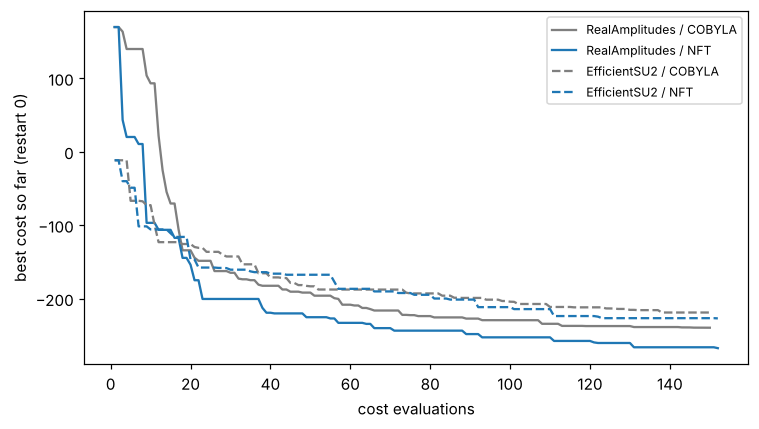

In [26]:
from qiskit_algorithms.optimizers import NFT

inst_A = Instance(make_instance(12, seed=0), 4)
op_A, _, _ = qiskit_penalty_op(inst_A, None)
est_A = StatevectorEstimator()
N_RESTARTS_A, BUDGET_A = 10, 150
nft_rows, nft_traces = [], {}
t0 = time.time()
for kind, builder in [('RealAmplitudes', real_amplitudes), ('EfficientSU2', efficient_su2)]:
    ans = transpile(builder(12, reps=2, entanglement='linear'), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
    for r in range(N_RESTARTS_A):
        x0 = np.random.default_rng(100 + r).uniform(0, 2 * np.pi, ans.num_parameters)
        for opt_name in ['COBYLA', 'NFT']:
            hist = []
            def f_A(x, a=ans, h=hist):
                v = float(est_A.run([(a, [op_A], [x])]).result()[0].data.evs[0]); h.append(v); return v
            res = (QK_COBYLA(maxiter=BUDGET_A) if opt_name == 'COBYLA' else NFT(maxfev=BUDGET_A)).minimize(f_A, x0=x0)
            nft_rows.append({'ansatz': kind, 'restart': r, 'optimizer': opt_name, 'final_cost': res.fun, 'nfev': len(hist)})
            if r == 0:
                nft_traces[(kind, opt_name)] = hist
nft_df = pd.DataFrame(nft_rows)
nft_df.to_csv(f'{RESULTS_DIR}/appendixA_nft_vs_cobyla.csv', index=False)
print(f'[{time.time() - t0:.0f}s]')
for kind in ['RealAmplitudes', 'EfficientSU2']:
    s_ = nft_df[nft_df.ansatz == kind].pivot(index='restart', columns='optimizer', values='final_cost')
    diff = (s_['NFT'] - s_['COBYLA']).values
    print(f"{kind:15s} COBYLA {s_['COBYLA'].mean():.1f} ± {s_['COBYLA'].std():.1f}   NFT {s_['NFT'].mean():.1f} ± {s_['NFT'].std():.1f}   "
          f"NFT - COBYLA = {fmt_ci(boot_ci(diff, seed=4), 1)}  (NFT better in {(diff < 0).sum()}/{len(diff)}, Wilcoxon p = {wilcoxon(diff).pvalue:.3g})")

fig, ax = plt.subplots(figsize=(7, 4))
for kind, ls in [('RealAmplitudes', '-'), ('EfficientSU2', '--')]:
    for opt_name, color in [('COBYLA', '#7f7f7f'), ('NFT', '#1f77b4')]:
        h = np.minimum.accumulate(nft_traces[(kind, opt_name)])
        ax.plot(np.arange(1, len(h) + 1), h, ls, color=color, label=f'{kind} / {opt_name}')
ax.set_xlabel('cost evaluations'); ax.set_ylabel('best cost so far (restart 0)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Limits: one instance; the final cost is the penalty energy, not coverage; NFT's advantage is
expected from its assumption, so this is a check of the implementation rather than a finding
about the problem.

## Appendix B. A learned initialiser for penalty QAOA (negative result)

A ridge regression maps the instance's coverage counts $c_i/25$ to QAOA parameters ($p = 2$,
penalty $P_\text{auto}$), trained on parameters optimised from one fixed starting point. On held-out
instances it is compared, at the same per-run budget, with that fixed start and with the best
of 3 random restarts (3× the budget). Earlier version: 14 training / 5 test instances;
here 60 / 30. Metric: exact $E[\text{ratio}\mid\text{feasible}]$.

In [27]:
N_TRAIN_B, N_TEST_B, P_B, LABEL_MAXITER_B, TEST_MAXITER_B, RIDGE_ALPHA = 60, 30, 2, 60, 40, 1.0
FIXED_U = np.r_[np.full(P_B, 0.5), np.full(P_B, np.pi / 4)]
gs_B = GAMMA_SCALE['penalty_auto']

X_tr, Y_tr = [], []
for s in range(N_TRAIN_B):
    inst_b = Instance(make_instance(12, seed=200000 + s), 4)
    *_, u_best = optimise_qaoa(inst_b, 'penalty_auto', P_B, 1, 0, gs_B, LABEL_MAXITER_B, x0_fixed=FIXED_U)
    X_tr.append(inst_b.c / 25); Y_tr.append(u_best)
X_tr, Y_tr = np.array(X_tr), np.array(Y_tr)
Xb = np.hstack([X_tr, np.ones((N_TRAIN_B, 1))])
W_B = np.linalg.solve(Xb.T @ Xb + RIDGE_ALPHA * np.eye(Xb.shape[1]), Xb.T @ Y_tr)

rows_B = []
for s in range(N_TEST_B):
    inst_b = Instance(make_instance(12, seed=210000 + s), 4)
    pred = np.r_[inst_b.c / 25, 1.0] @ W_B
    out = {}
    for name, x0 in [('learned', pred), ('fixed', FIXED_U)]:
        _, pr, *_ = optimise_qaoa(inst_b, 'penalty_auto', P_B, 1, 0, gs_B, TEST_MAXITER_B, x0_fixed=x0)
        out[name] = output_metrics(inst_b, pr)['ratio_cond']
    _, pr, *_ = optimise_qaoa(inst_b, 'penalty_auto', P_B, 3, 220000 + s, gs_B, TEST_MAXITER_B)
    out['best_of_3_random'] = output_metrics(inst_b, pr)['ratio_cond']
    rows_B.append({'instance': s, **out, 'random_subset': inst_b.random_mean_ratio})
pred_df = pd.DataFrame(rows_B)
pred_df.to_csv(f'{RESULTS_DIR}/appendixB_learned_init.csv', index=False)
for col in ['fixed', 'learned', 'best_of_3_random', 'random_subset']:
    print(f'{col:18s} E[ratio|feasible] = {fmt_ci(boot_ci(pred_df[col], seed=5))}')
d_B = (pred_df.learned - pred_df.fixed).values
print(f'learned - fixed = {fmt_ci(boot_ci(d_B, seed=6))}, Wilcoxon p = {wilcoxon(d_B).pvalue if np.any(d_B) else 1:.3g}')

fixed              E[ratio|feasible] = 0.650 [0.634, 0.666]
learned            E[ratio|feasible] = 0.650 [0.634, 0.666]
best_of_3_random   E[ratio|feasible] = 0.650 [0.634, 0.666]
random_subset      E[ratio|feasible] = 0.649 [0.633, 0.665]
learned - fixed = 0.000 [-0.000, 0.000], Wilcoxon p = 0.0345


Reading: all three initialisations give the same expected ratio to three decimals, equal to
the uniform-random value, consistent with Result 1 — when the ansatz itself puts almost no
weight on good feasible strings, a better starting point has nothing to work with. A linear model on station-ordered features also ignores
the permutation symmetry of the problem. This appendix validates the pipeline only.

## Appendix C. Multi-angle QAOA and the depth / parameter-count confound

ma-QAOA (Herrman et al. 2022) gives every Pauli term $Z_S$ of the cost its own angle $\gamma_{l,S}$
and every qubit its own $\beta_{l,q}$; with $\gamma_{l,S} = \gamma_l a_S$ and $\beta_{l,q} = \beta_l$ it reduces to standard QAOA
(checked below). The previous version compared standard QAOA at $p=1$ and $p=45$ with
ma-QAOA at $p=1$ — two points, one instance, a finite difference on one parameter. Here:
cost variance and exact gradients of all parameters, standard QAOA at $p \in \{1,2,3,5,10,20,45\}$, ma-QAOA at $p\in\{1,2\}$,
5 instances, penalty cost $P_\text{auto}$ (rescaled observable as in Section 6).

ma-QAOA -> standard QAOA reduction: 1 - fidelity = 5.8e-15; ma-QAOA p=1 has 90 parameters


[133s]


n_params  var_cost cost_ci_lo cost_ci_hi mean_var_grad grad_ci_lo grad_ci_hi
ansatz        p                                                                               
standard QAOA 1          2  4.45e-03   2.85e-03   6.08e-03      1.17e+02   4.78e+01   2.19e+02
              2          4  3.25e-03   1.97e-03   4.89e-03      5.93e+01   3.55e+01   8.81e+01
              3          6  1.38e-03   8.10e-04   2.00e-03      2.95e+01   1.98e+01   3.99e+01
              5         10  2.55e-04   1.50e-04   3.79e-04      6.63e+00   4.34e+00   1.05e+01
              10        20  2.13e-05   1.45e-05   2.96e-05      2.05e+00   1.64e+00   2.49e+00
              20        40  8.70e-06   6.28e-06   1.16e-05      1.56e+00   1.11e+00   1.94e+00
              45        90  7.94e-06   6.06e-06   9.94e-06      1.67e+00   1.21e+00   2.06e+00
ma-QAOA       1         90  3.25e-06   1.95e-06   4.98e-06      1.67e-06   1.42e-06   1.97e-06
              2        180  3.57e-06   2.86e-06   4.30e-06      3.52e-06   3.37e-06   3.58e-06

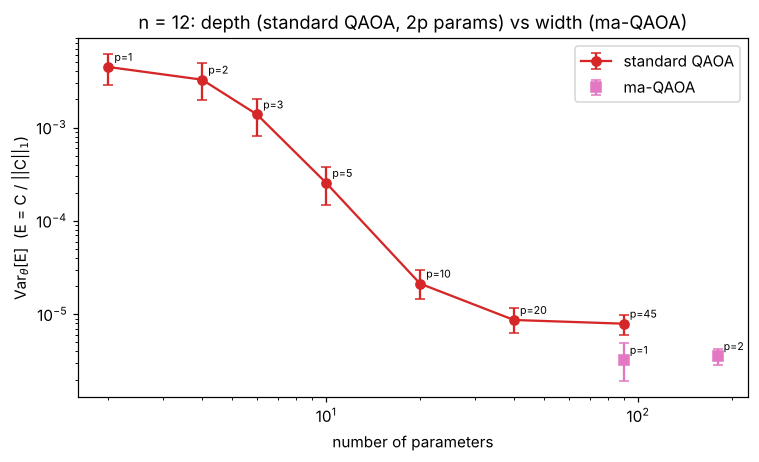

In [28]:
def ma_qaoa_gates(inst, d, p):
    a = z_coeffs(d)
    terms = [S for S in range(1, d.size) if abs(a[S]) > 1e-12]
    B = bit_table(inst.n).astype(np.int64)
    zdiag = {S: np.prod(np.where(B[:, [i for i in range(inst.n) if (S >> i) & 1]] == 1, -1.0, 1.0), axis=1) for S in terms}
    gates, idx = [], 0
    for _ in range(p):
        for S in terms:
            gates.append(('diag', zdiag[S], idx, 1.0)); idx += 1
        for q in range(inst.n):
            gates.append(('rx', q, idx, 2.0)); idx += 1
    return gates, idx, terms, a


inst_C = train_insts[12][0]
d_C = cost_diag(inst_C, 'penalty_auto')
g_ma, n_ma, terms_C, a_C = ma_qaoa_gates(inst_C, d_C, 2)
gam, bet = np.array([0.37, 0.11]), np.array([0.61, 0.23])
th_ma = np.concatenate([np.r_[gam[l] * a_C[terms_C], np.full(inst_C.n, bet[l])] for l in range(2)])
sim_C = Sim(inst_C.n)
fid_C = abs(np.vdot(sim_C.state(plus_state(12), g_ma, th_ma), sim_C.state(plus_state(12), gates_transverse(12, d_C, 2), np.r_[gam, bet]))) ** 2
print(f'ma-QAOA -> standard QAOA reduction: 1 - fidelity = {1 - fid_C:.1e}; ma-QAOA p=1 has {n_ma // 2} parameters')
assert 1 - fid_C < 1e-9

SAMPLES_C, STD_P_C, MA_P_C = 100, [1, 2, 3, 5, 10, 20, 45], [1, 2]
ma_rows = []
t0 = time.time()
for p in STD_P_C:
    Gs = []
    for i, inst_t in enumerate(train_insts[12]):
        d_t = cost_diag(inst_t, 'penalty_auto')
        rng = np.random.default_rng(SEED + 41 * i + p)
        gates_t, obs = gates_transverse(12, d_t, p), d_t / pauli_one_norm(d_t)
        Gs.append(np.array([np.r_[eg[0], eg[1]] for eg in (Sim(12).energy_and_grad(plus_state(12), gates_t, rng.uniform(np.zeros(2 * p), np.r_[np.full(p, 2 * np.pi), np.full(p, np.pi)]), obs, 2 * p)
                                                     for _ in range(SAMPLES_C))]))
    b, bc = boot_mean_var(Gs, 'grad', seed=p), boot_mean_var(Gs, 'cost', seed=p)
    ma_rows.append({'ansatz': 'standard QAOA', 'p': p, 'n_params': 2 * p, 'var_cost': mean_var(Gs, 'cost'),
                    'cost_ci_lo': np.quantile(bc, .025), 'cost_ci_hi': np.quantile(bc, .975),
                    'mean_var_grad': mean_var(Gs, 'grad'), 'grad_ci_lo': np.quantile(b, .025), 'grad_ci_hi': np.quantile(b, .975)})
for p in MA_P_C:
    Gs = []
    for i, inst_t in enumerate(train_insts[12]):
        d_t = cost_diag(inst_t, 'penalty_auto')
        gates_t, n_par, terms_t, _ = ma_qaoa_gates(inst_t, d_t, p)
        rng = np.random.default_rng(SEED + 43 * i + p)
        hi = np.concatenate([np.r_[np.full(len(terms_t), 2 * np.pi), np.full(12, np.pi)] for _ in range(p)])
        obs = d_t / pauli_one_norm(d_t)
        Gs.append(np.array([np.r_[eg[0], eg[1]] for eg in (Sim(12).energy_and_grad(plus_state(12), gates_t, rng.uniform(0, hi), obs, n_par) for _ in range(SAMPLES_C))]))
    b, bc = boot_mean_var(Gs, 'grad', seed=100 + p), boot_mean_var(Gs, 'cost', seed=100 + p)
    ma_rows.append({'ansatz': 'ma-QAOA', 'p': p, 'n_params': int(np.mean([G.shape[1] - 1 for G in Gs])), 'var_cost': mean_var(Gs, 'cost'),
                    'cost_ci_lo': np.quantile(bc, .025), 'cost_ci_hi': np.quantile(bc, .975),
                    'mean_var_grad': mean_var(Gs, 'grad'), 'grad_ci_lo': np.quantile(b, .025), 'grad_ci_hi': np.quantile(b, .975)})
ma_df = pd.DataFrame(ma_rows)
ma_df.to_csv(f'{RESULTS_DIR}/appendixC_ma_qaoa.csv', index=False)
print(f'[{time.time() - t0:.0f}s]')
display(ma_df.set_index(['ansatz', 'p']).apply(lambda c: c.map(lambda v: f'{v:.2e}') if c.name != 'n_params' else c))

fig, ax = plt.subplots(figsize=(7, 4.3))
for name, mk, col in [('standard QAOA', 'o-', '#d62728'), ('ma-QAOA', 's', '#e377c2')]:
    s_ = ma_df[ma_df.ansatz == name]
    ax.errorbar(s_.n_params, s_.var_cost, yerr=[s_.var_cost - s_.cost_ci_lo, s_.cost_ci_hi - s_.var_cost], fmt=mk, color=col, capsize=3, label=name)
    for _, r in s_.iterrows():
        ax.annotate(f'p={r.p}', (r.n_params, r.var_cost), textcoords='offset points', xytext=(4, 4), fontsize=7)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('number of parameters'); ax.set_ylabel(r'Var$_\theta$[E]  (E = C / ||C||$_1$)')
ax.set_title('n = 12: depth (standard QAOA, 2p params) vs width (ma-QAOA)'); ax.legend()
plt.tight_layout(); plt.show()

Reading. The cost variance $\mathrm{Var}_\theta[E]$ (plotted) is the comparable quantity across these
parametrisations; the gradient variance (table) is not, because a standard-QAOA $\gamma$ multiplies the
whole cost operator (coefficients up to $P_\text{auto} \approx 40$), while each ma-QAOA angle multiplies one
unit-weight Pauli term — the gradients differ by orders of magnitude for that reason alone.
For standard QAOA, $\mathrm{Var}[E]$ falls with depth and levels off from $p \approx 10$–$20$ at about $10^{-5}$;
ma-QAOA is already at that level at $p = 1$ (90 parameters, depth of a single layer). At equal
parameter count (standard $p = 45$ vs ma-QAOA $p = 1$) the two are of the same order. So the
previous version's conclusion (deep-thin "three orders of magnitude less barren" than
shallow-wide) was an artefact of comparing gradients in different units; what the data show is
that giving every term its own angle makes the landscape as concentrated as a very deep standard
circuit, i.e. expressibility rather than depth drives the concentration here. One size ($n = 12$) only.

## Appendix D. Warm-starting QAOA from the LP relaxation

Warm start (Egger, Marecek & Woerner 2021): qubit $i$ starts in $R_Y(\theta_i)\lvert0\rangle$ with
$\theta_i = 2\arcsin\sqrt{\tilde x_i}$, $\tilde x_i = \mathrm{clip}(x_i^\star, \epsilon, 1-\epsilon)$, $\epsilon = 0.25$, and the mixer of qubit $i$ is
$e^{-i\beta H_i}$ with $H_i = (\sin\theta_i) X_i + (\cos\theta_i) Z_i = 2\sqrt{\tilde x_i(1-\tilde x_i)}\,X_i - (2\tilde x_i - 1) Z_i$. The initial
single-qubit state has Bloch vector $(\sin\theta_i, 0, \cos\theta_i)$, so it is the $+1$ eigenstate of $H_i$ —
the same relation as $\lvert+\rangle$ and $X$ in standard QAOA. (The previous version described it as the
*ground* state; it is the top eigenstate.) For $\tilde x_i = 1/2$ it reduces to standard QAOA (checked below).

The previous version tested one instance whose LP solution was already integral (the warm
start was the answer). Here: 10 instances of family R ($n = 12$) and the 12 instances of
family H, where LP rounding fails by construction; penalty cost $P_\text{tight}$; matched restarts.

In [29]:
WS_EPS, WS_RESTARTS = 0.25, 3


def warmstart_built(inst, x_star, p, method='penalty_tight'):
    n = inst.n
    x = np.clip(x_star, WS_EPS, 1 - WS_EPS)
    th = 2 * np.arcsin(np.sqrt(x))
    psi0 = np.array([1.0 + 0j])
    for q in reversed(range(n)):                 # qubit n-1 is the most significant tensor factor
        psi0 = np.kron(psi0, [np.cos(th[q] / 2), np.sin(th[q] / 2)])
    d = cost_diag(inst, method)
    I2, X, Z = np.eye(2), np.array([[0, 1], [1, 0]]), np.diag([1.0, -1.0])
    def mixer_fn(Hq):
        return lambda b: np.cos(b) * I2 - 1j * np.sin(b) * Hq
    gates = []
    for l in range(p):
        gates.append(('diag', d, l, 1.0))
        gates += [('par1', q, mixer_fn(np.sin(th[q]) * X + np.cos(th[q]) * Z), p + l) for q in range(n)]
    return Sim(n), gates, psi0, d


inst_D0 = train_insts[12][0]
b_ws = warmstart_built(inst_D0, np.full(12, 0.5), 2)
b_std = ansatz_for(inst_D0, 'penalty_tight', 2)
th_D = np.array([0.3, 0.2, 0.5, 0.9])
fid_D = abs(np.vdot(b_ws[0].state(b_ws[2], b_ws[1], th_D), b_std[0].state(b_std[2], b_std[1], th_D))) ** 2
print(f'warm start with x* = 1/2 -> standard QAOA: 1 - fidelity = {1 - fid_D:.1e}')
assert 1 - fid_D < 1e-9

ws_insts = [(f, i_) for f, i_ in ensemble if f == 'R' and i_.n == 12][:10] + [(f, i_) for f, i_ in ensemble if f == 'H']
ws_rows = []
t0 = time.time()
for j, (fam, inst_d) in enumerate(ws_insts):
    x_star, _ = lp_relaxation(inst_d.cov, inst_d.k)
    frac = float(np.mean((x_star > 1e-6) & (x_star < 1 - 1e-6)))
    for p in [1, 2, 3]:
        for name, built in [('warm start', warmstart_built(inst_d, x_star, p)), ('standard', None)]:
            _, pr, *_ = optimise_qaoa(inst_d, 'penalty_tight', p, WS_RESTARTS, SEED + 13 * j + p, GAMMA_SCALE['penalty_tight'], MAXITER, built=built)
            ws_rows.append({'family': fam, 'instance': inst_d.name, 'lp_fraction_fractional': frac, 'p': p, 'variant': name,
                            'lp_topk_ratio': lp_topk(inst_d.cov, inst_d.k)[1] / inst_d.opt, **output_metrics(inst_d, pr)})
ws_df = pd.DataFrame(ws_rows)
ws_df.to_csv(f'{RESULTS_DIR}/appendixD_warm_start.csv', index=False)
print(f'[{time.time() - t0:.0f}s]')
ws_tab = ws_df.groupby(['family', 'p', 'variant'])[['ratio_cond', 'p_opt', 'p_feasible', 'ratio_top1']].mean().round(3)
display(ws_tab)
print('mean fraction of fractional LP variables:', ws_df.groupby('family')['lp_fraction_fractional'].mean().round(3).to_dict())

warm start with x* = 1/2 -> standard QAOA: 1 - fidelity = -8.9e-16


[194s]


ratio_cond  p_opt  p_feasible  ratio_top1
family p variant                                              
H      1 standard         0.731  0.005       0.435       0.988
         warm start       0.816  0.029       0.436       0.996
       2 standard         0.734  0.006       0.523       0.981
         warm start       0.822  0.040       0.553       1.000
       3 standard         0.733  0.007       0.571       0.928
         warm start       0.827  0.046       0.594       1.000
R      1 standard         0.680  0.006       0.433       1.000
         warm start       0.815  0.077       0.422       1.000
       2 standard         0.683  0.008       0.527       1.000
         warm start       0.828  0.116       0.563       1.000
       3 standard         0.683  0.009       0.568       0.954
         warm start       0.834  0.135       0.604       1.000

mean fraction of fractional LP variables: {'H': 0.375, 'R': 0.0}


Reading: on family R the LP relaxation is integral and optimal, so the warm-start state is
biased (each selected station with probability 0.75 after regularisation) towards the optimum,
and the warm start inherits that. On family H, where
deterministic LP rounding is wrong by construction, the comparison shows how much of the
warm start's advantage survives when the relaxation is not already the answer. Note the
regularisation $\epsilon$: with $\epsilon = 0.25$ the initial state still has substantial weight away from
$x^\star$, which is what lets the circuit leave a wrong LP solution.